## Mateus Ribeiro Gomes - 555225
### Trabalho Densidade Espectral de Potência

In [605]:
import numpy as np
from matplotlib import pyplot as plt

## Tarefa 1

O valor de $A$ escolhido para utilizar na equação $s_{int}(n) = A \cdot cos(2 \pi f_0 n + \phi)$ foi $A = \sqrt{2}$ para que a interferência do canal adjacente tenha mesma potência que o ruído (unitária).

Potência ($P$) de uma senoide com aplitude $A$ é dada por: $$P = \frac{A^2}{2}$$

In [606]:
# Definindo os dados fornecidos
n1 = 1024
n2 = 4096
a1 = 1.35
a2 = -0.85
f0 = 0.45
phi = np.random.uniform(0, 2 * np.pi)
alpha = 0.72
D = 4

#### Função para gerar o 

#### $x(n) = a_1 \cdot x(n-1) + a_2 \cdot x(n-2) + u(n)$

In [607]:
gerar_ruido = lambda n, var : np.random.normal(0, np.sqrt(var), n)

def gerar_x(n):
    u = gerar_ruido(n, 1.0) 
    xret = np.zeros(n)
    for i in range(n):
        if i == 0:
            xret[i] = u[i]
        elif i == 1:
            xret[i] = a1 * xret[i-1] + u[i]
        else:
            xret[i] = a1 * xret[i-1] + a2 * xret[i-2] + u[i]
            
    return xret

#### Função para modelar o filtro FIR
#### $h(n) = \delta(n) + \alpha \cdot \delta (n-D)$

In [608]:
def aplicar_canal(x):
    y = np.zeros(len(x))
    # As primeiras D amostras não sofrem interferência 
    y[:D] = x[:D]
    # A partir de D, o sinal é a soma do caminho direto com o percurso atrasado
    y[D:] = x[D:] + alpha * x[:-D]
    return y

#### Função para a interferência
#### $s_{int}(n) = A \cdot cos(2 \pi f_0 n + \phi)$

In [609]:
def sint(n, A):
    return A * np.cos(2*np.pi*f0*n + phi)

#### Função para calcular a variância dada as diferentes relações sinal ruído
#### $SNR_{db} = 10 \cdot log_{10} \cdot (\frac{P_{signal}}{P_{noise}})$, queremos achar o $P_{noise}$

In [610]:
def var_given_db(y, db):
    pot = np.mean(y**2)
    var = pot / (10**(db/10))
    return var

#### Função final que combina tudo

Semelhante a escolhe de $A = $, foi escolhido $\sigma_w ^ 2 = 1$ para que a potência do AWGN fosse igual ao ruído presnete em $x(n)$

In [611]:
def ar2(n, A, snr_db=None, var_w_direto=None):
    xtemp = gerar_x(n)
    y = aplicar_canal(xtemp)
    if var_w_direto is not None:
        var_final = var_w_direto
    elif snr_db is not None:
        var_final = var_given_db(y, snr_db)
    else:
        raise ValueError("Voce deve fornecer ou snr_db ou var_w_direto")
    sinterf = sint(np.arange(n), A)
    w = gerar_ruido(n, var_final)
    r = y + sinterf + w
    return r, var_final

In [612]:
ar_1024 = ar2(n=n1, A=np.sqrt(2), var_w_direto=1)
ar_4096 = ar2(n=n2, A=np.sqrt(2), var_w_direto=1)

#### Plotando

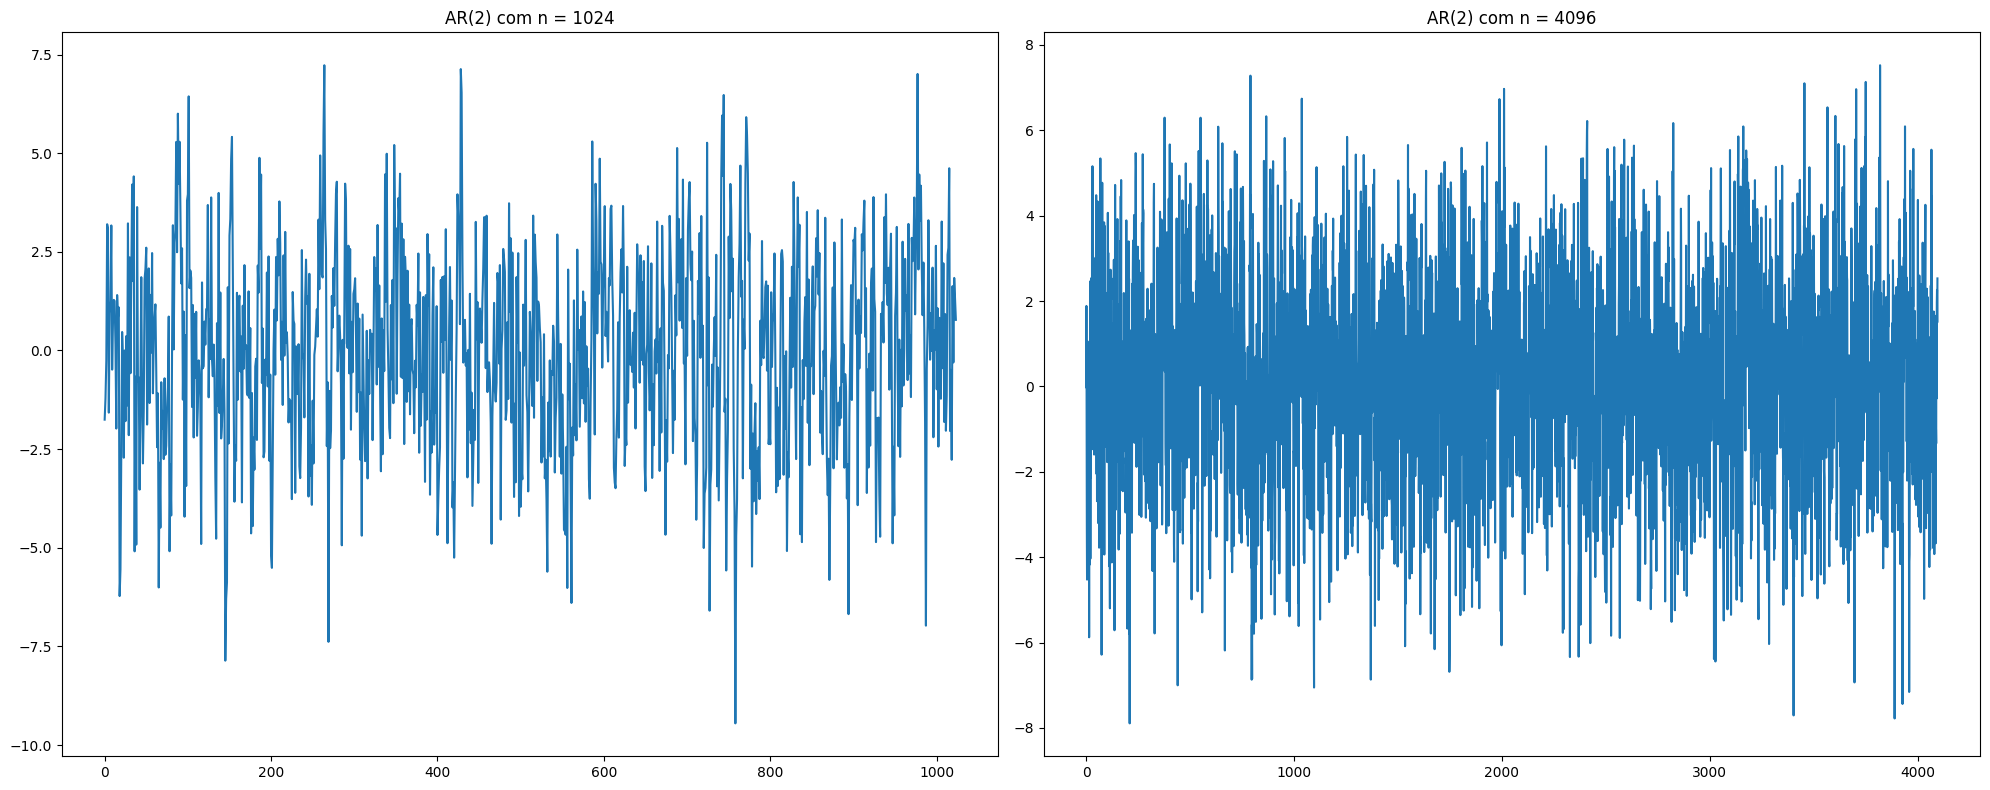

In [613]:
N1 = np.arange(n1)
N2 = np.arange(n2)

fig, axs = plt.subplots(1, 2, figsize=(20, 8))

axs[0].plot(N1, ar_1024[0])
axs[0].set_title('AR(2) com n = 1024')

axs[1].plot(N2, ar_4096[0])
axs[1].set_title('AR(2) com n = 4096')

plt.tight_layout()
plt.show()

## Tarefa 2

#### Variando os valores de "A" e $\sigma^2_w$

Os valores escolhidos foram:

#### 1. Amplitudes de Interferência A

As escolhas foram feitas visando diferentes cenários de potência da interferência do canal adjacente $P = \frac{A^2}{2}$

* **A = 0.5**: Interferência fraca com potência 0.125. Serve como linha de base para observar o formato do espectro original com distorções mínimas.

* **A = $\sqrt{2}$**: Cenário de potência unitária. Estabelece um equilíbrio energético perfeito, igualando a força da interferência à variância do ruído gaussiano original.

* **A = 5**: Interferência severa com potência 12.5. O tom senoidal domina o espectro e reduz a margem dinâmica de visualização do sinal de dados.

* **A = 10**: Interferência extrema com potência 50. Testa o limite de falha do algoritmo, esmagando completamente o sinal útil no gráfico.

#### 2. Variância ajustável $\sigma_w ^ 2$

As escolhas foram feitas visando difentes signal-noise ratio $SNR_{db} = 10 \cdot log_{10} \cdot \frac{P_{signal}}{P_{noise}}$

* **0 dB**: Degradação máxima. A potência do ruído é exatamente igual à potência do sinal recebido, mascarando as frequências do sistema.

* **10 dB**: Condição nominal. Canal de comunicação realista com ruído perceptível, exigindo eficiência do método para detectar a informação.

* **30 dB**: Canal de alta qualidade. Ruído baixo, excelente para validar visualmente a resposta em frequência pura do filtro FIR.

* **50 dB**: Condição teórica ideal. O fundo de ruído é empurrado para o mínimo computacional possível, permitindo visualizar as ondulações "limpas".

In [ ]:
As = [0.5, np.sqrt(2), 5, 10]
dbs = [0, 15, 30, 50]
# ar2s_1024 = [ar2(n1,a, db) for a in As for db in dbs]
# ar2s_4096 = [ar2(n2,a, db) for a in As for db in dbs]

sinais_1024 = []
sinais_4096 = []

linhas_1024 = []
linhas_4096 = []

w1, w2, w3, w4 = 14, 19, 21, 28

for a in As:
    for db in dbs:
        r_1024, var_1024 = ar2(n1, a, snr_db=db)
        sinais_1024.append((a, db, r_1024))
        
        r_4096, var_4096 = ar2(n2, a, snr_db=db)
        sinais_4096.append((a, db, r_4096))
        
        a_str = f"√2" if np.isclose(a, np.sqrt(2)) else f"{a:.1f}"
        
        linhas_1024.append(f"| {'1024':^{w1}} | {a_str:^{w2}} | {db:^{w3}} | {var_1024:^{w4}.4f} |")
        linhas_4096.append(f"| {'4096':^{w1}} | {a_str:^{w2}} | {db:^{w3}} | {var_4096:^{w4}.4f} |")


print(f"| {'N':^{w1}} | {'A':^{w2}} | {'SNR utilizado (dB)':^{w3}} | {'Variância ajustável (σ²_w)':^{w4}} |")
print(f"|{'-'*(w1+2)}|{'-'*(w2+2)}|{'-'*(w3+2)}|{'-'*(w4+2)}|")

for linha in linhas_1024:
    print(linha)

for linha in linhas_4096:
    print(linha)

|       N        |          A          |  SNR utilizado (dB)   |  Variância ajustável (σ²_w)  |
|----------------|---------------------|-----------------------|------------------------------|
|      1024      |         0.5         |           0           |            4.0455            |
|      1024      |         0.5         |          15           |            0.1272            |
|      1024      |         0.5         |          30           |            0.0037            |
|      1024      |         0.5         |          50           |            0.0000            |
|      1024      |         √2          |           0           |            4.7129            |
|      1024      |         √2          |          15           |            0.1119            |
|      1024      |         √2          |          30           |            0.0038            |
|      1024      |         √2          |          50           |            0.0000            |
|      1024      |         5.0         |           0           |            4.1061            |
|      1024      |         5.0         |          15           |            0.1245            |
|      1024      |         5.0         |          30           |            0.0044            |
|      1024      |         5.0         |          50           |            0.0000            |
|      1024      |        10.0         |           0           |            4.4363            |
|      1024      |        10.0         |          15           |            0.1414            |
|      1024      |        10.0         |          30           |            0.0040            |
|      1024      |        10.0         |          50           |            0.0000            |
|      4096      |         0.5         |           0           |            3.8300            |
|      4096      |         0.5         |          15           |            0.1229            |
|      4096      |         0.5         |          30           |            0.0036            |
|      4096      |         0.5         |          50           |            0.0000            |
|      4096      |         √2          |           0           |            3.9038            |
|      4096      |         √2          |          15           |            0.1370            |
|      4096      |         √2          |          30           |            0.0039            |
|      4096      |         √2          |          50           |            0.0000            |
|      4096      |         5.0         |           0           |            4.0600            |
|      4096      |         5.0         |          15           |            0.1192            |
|      4096      |         5.0         |          30           |            0.0040            |
|      4096      |         5.0         |          50           |            0.0000            |
|      4096      |        10.0         |           0           |            4.1025            |
|      4096      |        10.0         |          15           |            0.1297            |
|      4096      |        10.0         |          30           |            0.0039            |
|      4096      |        10.0         |          50           |            0.0000            |

Com base nos dados apresentados na tabela, é possível observar o seguinte comportamento da variância ajustável ($\sigma^2_w$):
- Em relação à SNR: A variância ajustável diminui conforme a SNR aumenta. Para uma SNR de 0 dB, a variância fica na faixa de 3.8 a 4.7. Esse valor cai para a casa de 0.11 a 0.14 em 15 dB, reduz para aproximadamente 0.004 em 30 dB e atinge 0.0000 em 50 dB.

- Em relação à A: Quando fixamos a SNR e o N, a mudança no valor de A (0.5, $\sqrt{2}$, 5.0 ou 10.0) não apresenta uma tendência de aumento ou diminuição contínua na variância. Os valores mostram apenas pequenas flutuações em torno de uma mesma faixa.

- Em relação a N: O aumento de N de 1024 para 4096 reduz a janela de oscilação da variância. No cenário de 0 dB, por exemplo, os valores variam de forma mais espaçada no bloco de N = 1024 (indo de 4.04 a 4.71) do que no bloco de N = 4096 (onde ficam mais contidos, entre 3.83 e 4.10).

### Plotando os casos gerados com todas as amostras

In [615]:
def plot_scenario_matrix_time(list, N, num_to_show = None):
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 8), sharex=True, sharey=True)
    fig.suptitle(f'Matriz de Cenários: Sinal Recebido r(n) no Tempo (N={N})', fontsize=16, fontweight='bold', y=0.98)

    indice_sinal = 0

    for i, a in enumerate(As):
        for j, db in enumerate(dbs):
            ax = axes[i, j]
            
            a_val, db_val, sinal_r = list[indice_sinal]

            if num_to_show is not None: 
                ax.plot(sinal_r[:num_to_show], color='#1f77b4', linewidth=1.2)
            else:
                ax.plot(sinal_r, color='#1f77b4', linewidth=1.2)
            
            if np.isclose(a_val, np.sqrt(2)):
                ax.set_title(f'A = $\sqrt{{2}}$ | SNR = {db} dB', fontsize=11)
            else:
                ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)

            ax.grid(True, linestyle='--', alpha=0.5)
            
            if i == 3:
                ax.set_xlabel('Amostras (n)')
            if j == 0:
                ax.set_ylabel('Amplitude')
                
            indice_sinal += 1

    plt.tight_layout()
    plt.show()

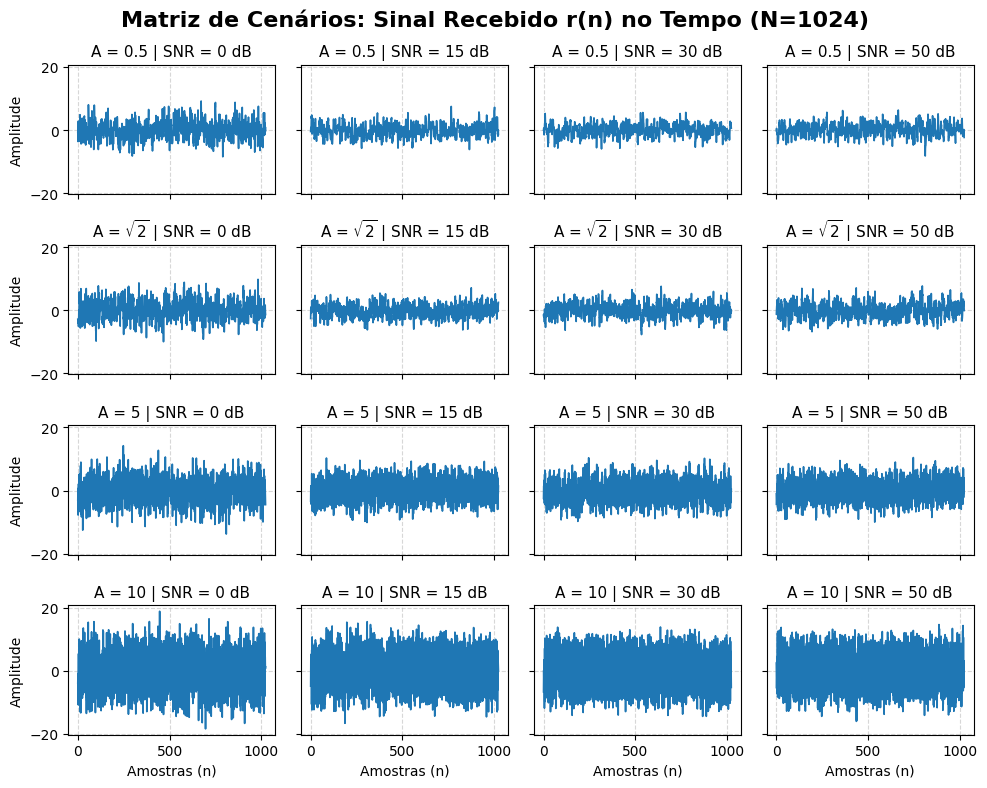

In [616]:
plot_scenario_matrix_time(list=sinais_1024, N = 1024)

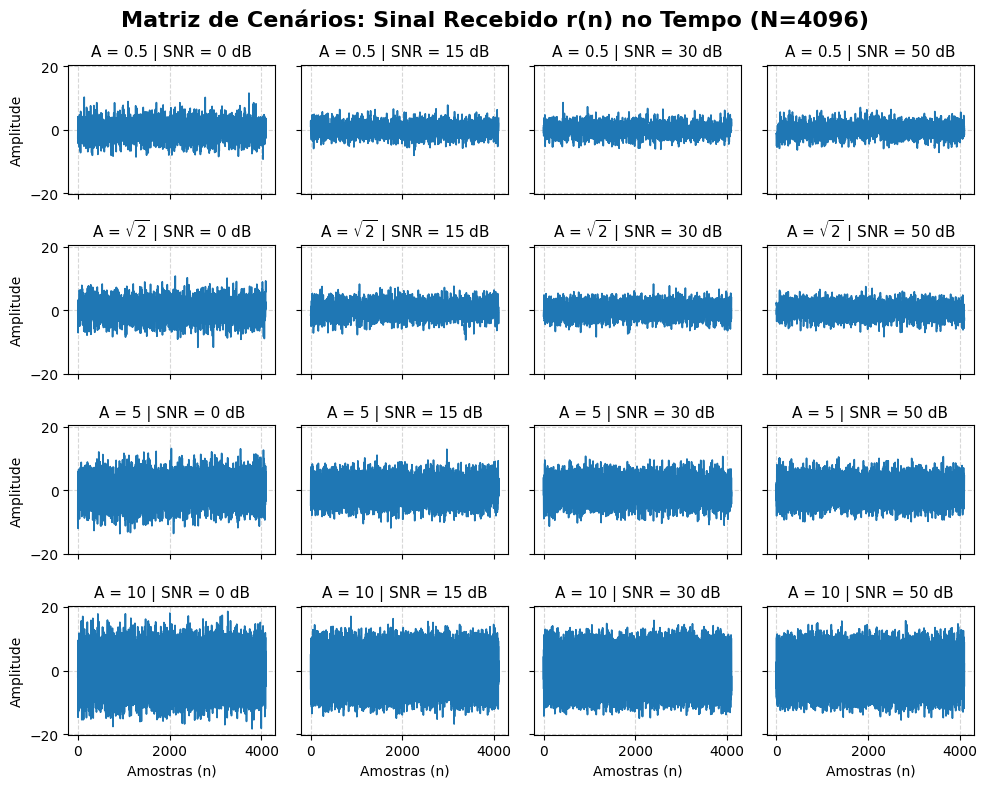

In [617]:
plot_scenario_matrix_time(list = sinais_4096, N = 4096)

### Plotando os casos gerados porém apenas as 100 primeiras amostras para melhor visualização

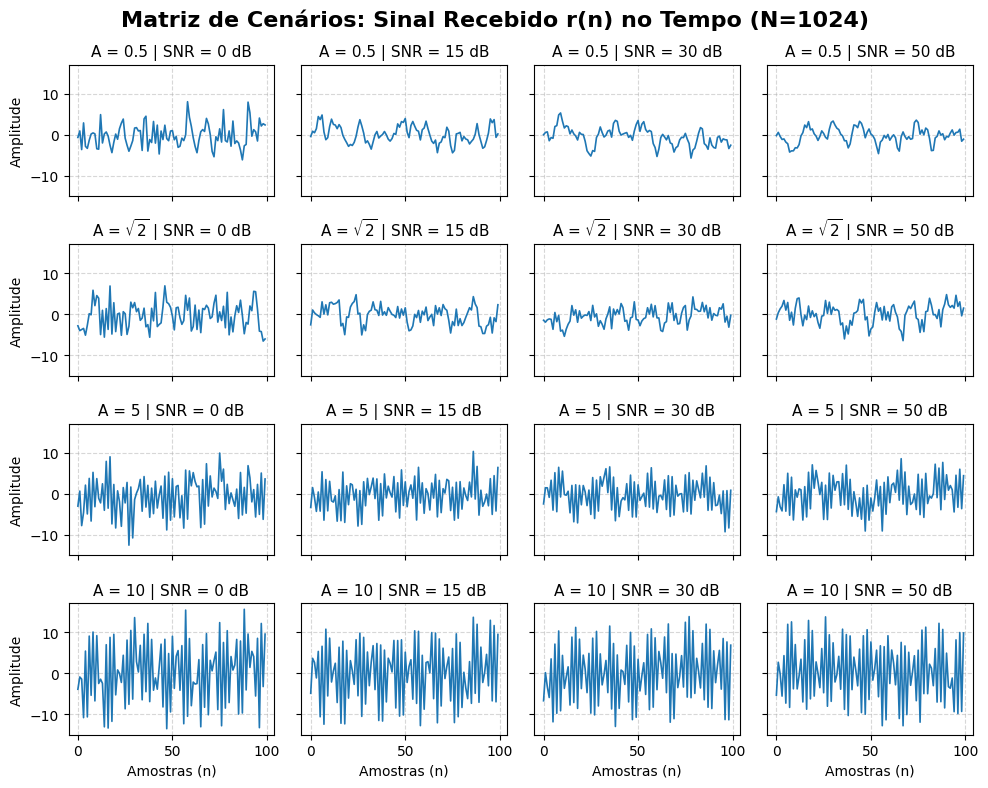

In [618]:
plot_scenario_matrix_time(list = sinais_1024, N = 1024, num_to_show=100)

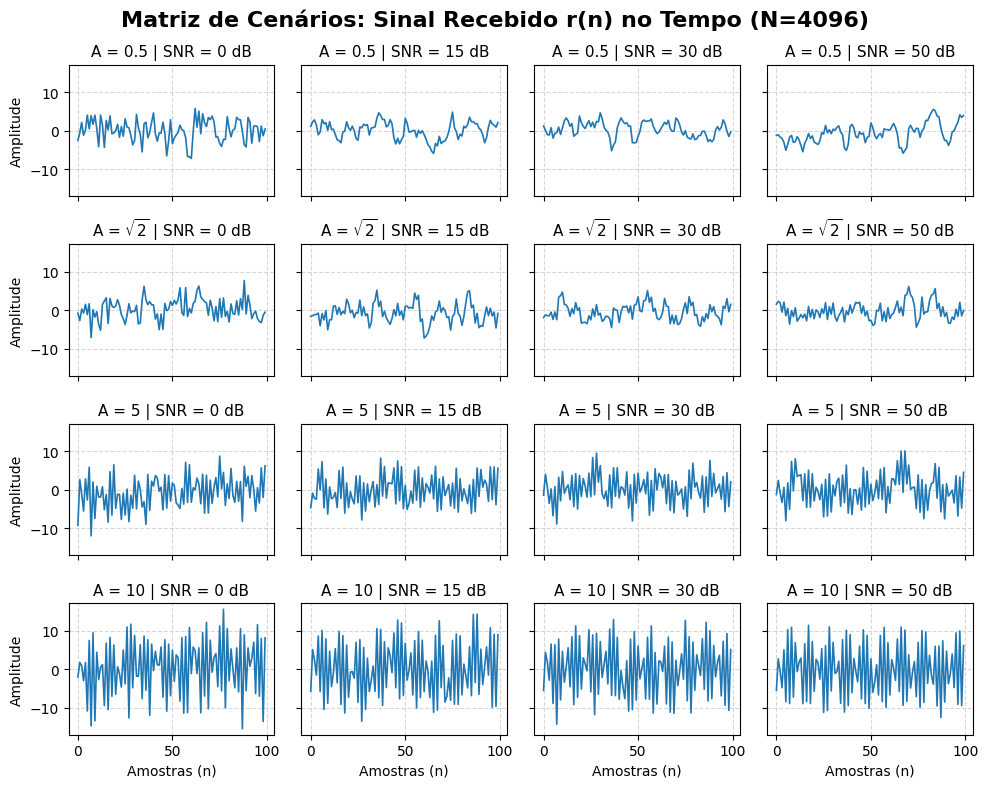

In [619]:
plot_scenario_matrix_time(list=sinais_4096, N = 4096, num_to_show=100)

## Tarefa 3

Para avaliar como o sistema modelado se comporta no domínio da frequência, é necessário extrair a sua Densidade Espectral de Potência DEP. Para tal, são empregados métodos de estimação não paramétricos clássicos, eles são: 

**1. Método do Periodograma**

O periodograma é o estimador espectral mais elementar, fundamentado diretamente na Transformada Discreta de Fourier DFT. A estratégia consiste em aplicar a transformada em toda a extensão do vetor de dados amostrado, calculando a DEP por meio do módulo ao quadrado dos coeficientes resultantes, normalizados pelo número total de amostras N. 

Apesar de fornecer a resolução máxima em frequência suportada pelo comprimento do sinal, sabemos que o periodograma clássico é um estimador estatisticamente inconsistente. Ao longo das iterações e do aumento de amostras, a variância da estimativa não converge para zero. O resultado é a geração de um espectro com severas flutuações e ruído visual.

**2. Método de Welch**

A fim de mitigar a alta variância característica do periodograma direto, o método de Welch aplica uma abordagem baseada em particionamento e médias. A obtenção da estimativa final segue os seguintes passos:

* **Passo 1:** O vetor original contendo a totalidade do sinal é subdividido em segmentos K menores de tamanho fixo.
* **Passo 2:** Para evitar distorções e o fenômeno de vazamento espectral causado pelo corte abrupto nas fronteiras de cada bloco, multiplica-se cada segmento por uma função de janelamento matemático.
* **Passo 3:** Calcula-se o periodograma individual, modificado pelo janelamento, de cada um dos K sub-blocos segmentados.
* **Passo 4:** O espectro final é obtido por meio da média aritmética de todos os periodogramas calculados na etapa anterior.

In [620]:
from scipy import signal

In [621]:
periodograms_1024 = []
periodograms_4096 = []

welch_1024 = []
welch_4096 = []


É válido comentar que para que se possa visualizar o resultado da maneira correta, faz-se necessario o uso da `np.fft.fftshift()` pois os algoritmos de Transformada Rápida de Fourier não retornam as componentes espectrais em ordem linear crescente.Por padrão de arquitetura, o vetor gerado por essas funções armazena primeiro a componente de nível nulo e todas as frequências positivas. Na segunda metade do array, são armazenadas as frequências negativas. Se esse vetor bruto for utilizado como parametro para o matplotlib, a função de desenho tentará conectar o último índice positivo ao primeiro índice negativo, gerando uma linha diagonal cortando todo o gráfico. A `fftshift` reorganiza de forma circular, ela empurra as frequências negativas para o início do array e centraliza a componente de nível nulo$

#### Gerando os periodogramas

In [622]:
for s in sinais_1024:
    amplitude, snr, sinal_r = s
    f, pxx = signal.periodogram(sinal_r, return_onesided=False)
    f_shift = np.fft.fftshift(f)
    pxx_shift = np.fft.fftshift(pxx)
    periodograms_1024.append((amplitude, snr, f_shift, pxx_shift))

for s in sinais_4096:
    amplitude, snr, sinal_r = s
    f, pxx = signal.periodogram(sinal_r, return_onesided=False)
    f_shift = np.fft.fftshift(f)
    pxx_shift = np.fft.fftshift(pxx)
    periodograms_4096.append((amplitude, snr, f_shift, pxx_shift))

#### Gerando a DEP com método de welch com tamanho de janela default `256`

In [623]:
for s in sinais_1024:
    amplitude, snr, sinal_r = s
    f, pxx = signal.welch(sinal_r, return_onesided=False)
    f_shift = np.fft.fftshift(f)
    pxx_shift = np.fft.fftshift(pxx)
    welch_1024.append((amplitude, snr, f_shift, pxx_shift))

for s in sinais_4096:
    amplitude, snr, sinal_r = s
    f, pxx = signal.welch(sinal_r, return_onesided=False)
    f_shift = np.fft.fftshift(f)
    pxx_shift = np.fft.fftshift(pxx)
    welch_4096.append((amplitude, snr, f_shift, pxx_shift))

#### Plotando o periodograma para os sinais

In [624]:
def plot_scenario_matrix_freq(list, N, method, scale=None):
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 10), sharex=True, sharey=True)
    fig.suptitle(f'Matriz de Cenários: {method} para N = {N}', fontsize=16, fontweight='bold', y=0.98)

    indice_sinal = 0

    for i, a in enumerate(As):
        for j, db in enumerate(dbs):
            ax = axes[i, j]
            
            _, _, f, pxx = list[indice_sinal]
            if scale is None:
                ax.plot(f, pxx,color='#1f77b4', linewidth=1.2)
            elif scale == "db":
                ax.plot(f, 10*np.log10(np.maximum(pxx, 1e-10)),color='#1f77b4', linewidth=1.2)
            ax.axvline(x=0.45, color='red', linestyle='--', alpha=0.5, linewidth=1)
            ax.axvline(x=-0.45, color='red', linestyle='--', alpha=0.5, linewidth=1)
            if np.isclose(a, np.sqrt(2)):
                ax.set_title(f'A = $\sqrt{{2}}$ | SNR = {db} dB', fontsize=11)
            else:
            #ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
                ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
            ax.grid(True, linestyle='--', alpha=0.5)
            
            if i == 3:
                ax.set_xlabel('$f$')
            if j == 0:
                ax.set_ylabel('$S_r(f)$') if scale is None else ax.set_ylabel('$S_r(f)$ dB')
                
            indice_sinal += 1

    plt.tight_layout()
    plt.show()

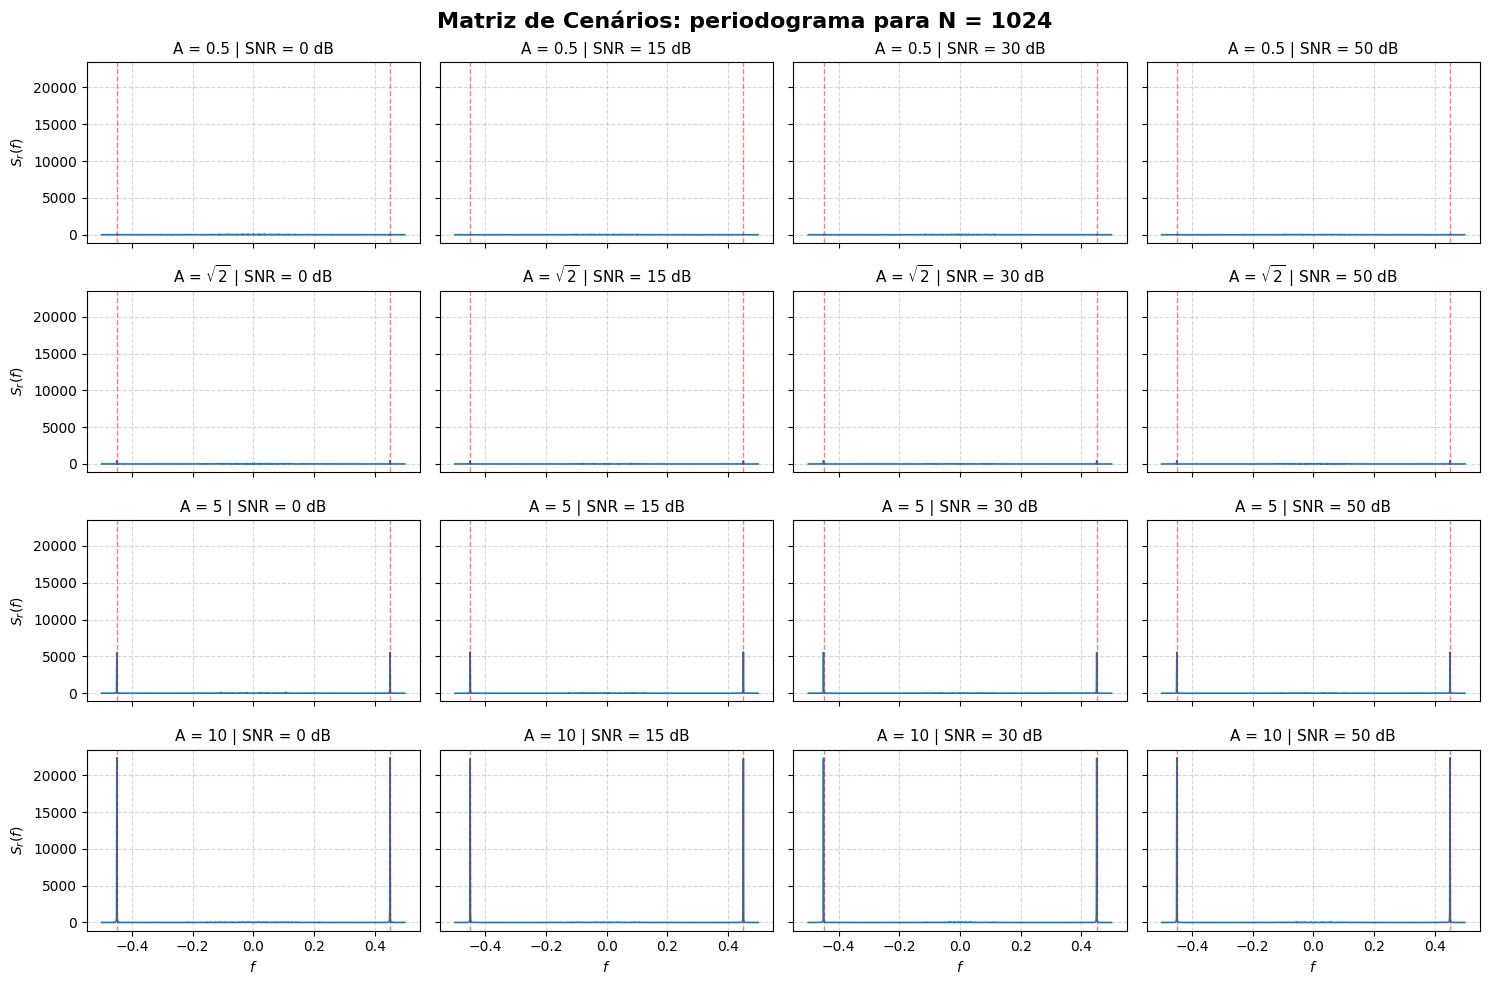

In [625]:
plot_scenario_matrix_freq(list = periodograms_1024, N = 1024, method = "periodograma")

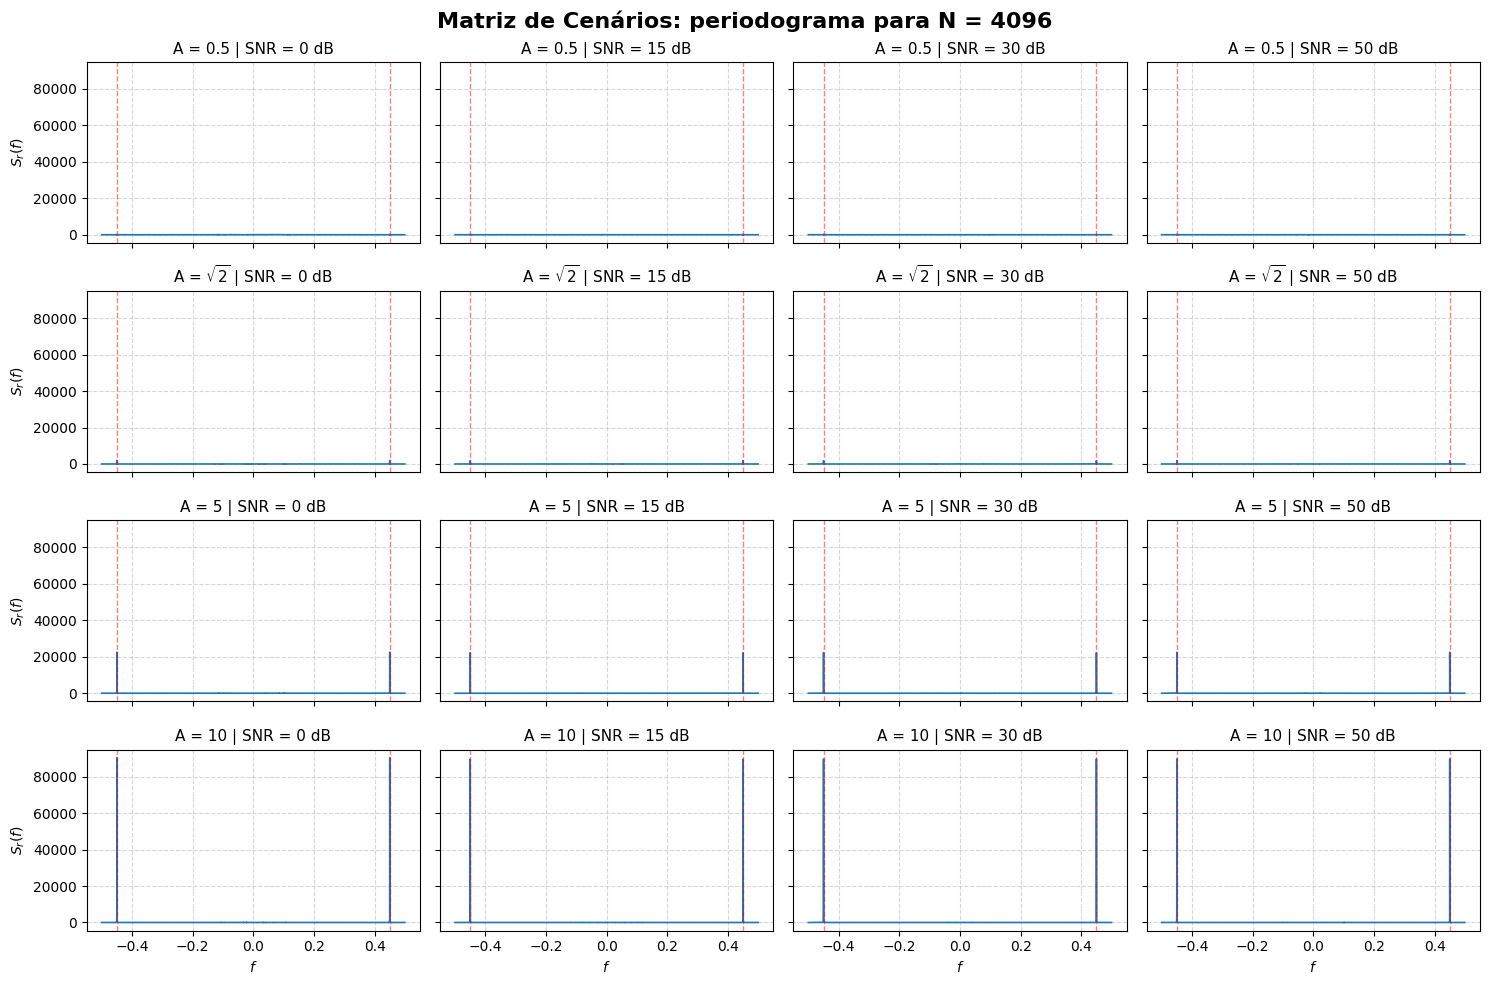

In [626]:
plot_scenario_matrix_freq(periodograms_4096, N = 4096, method="periodograma")

#### Em escala logaritmica

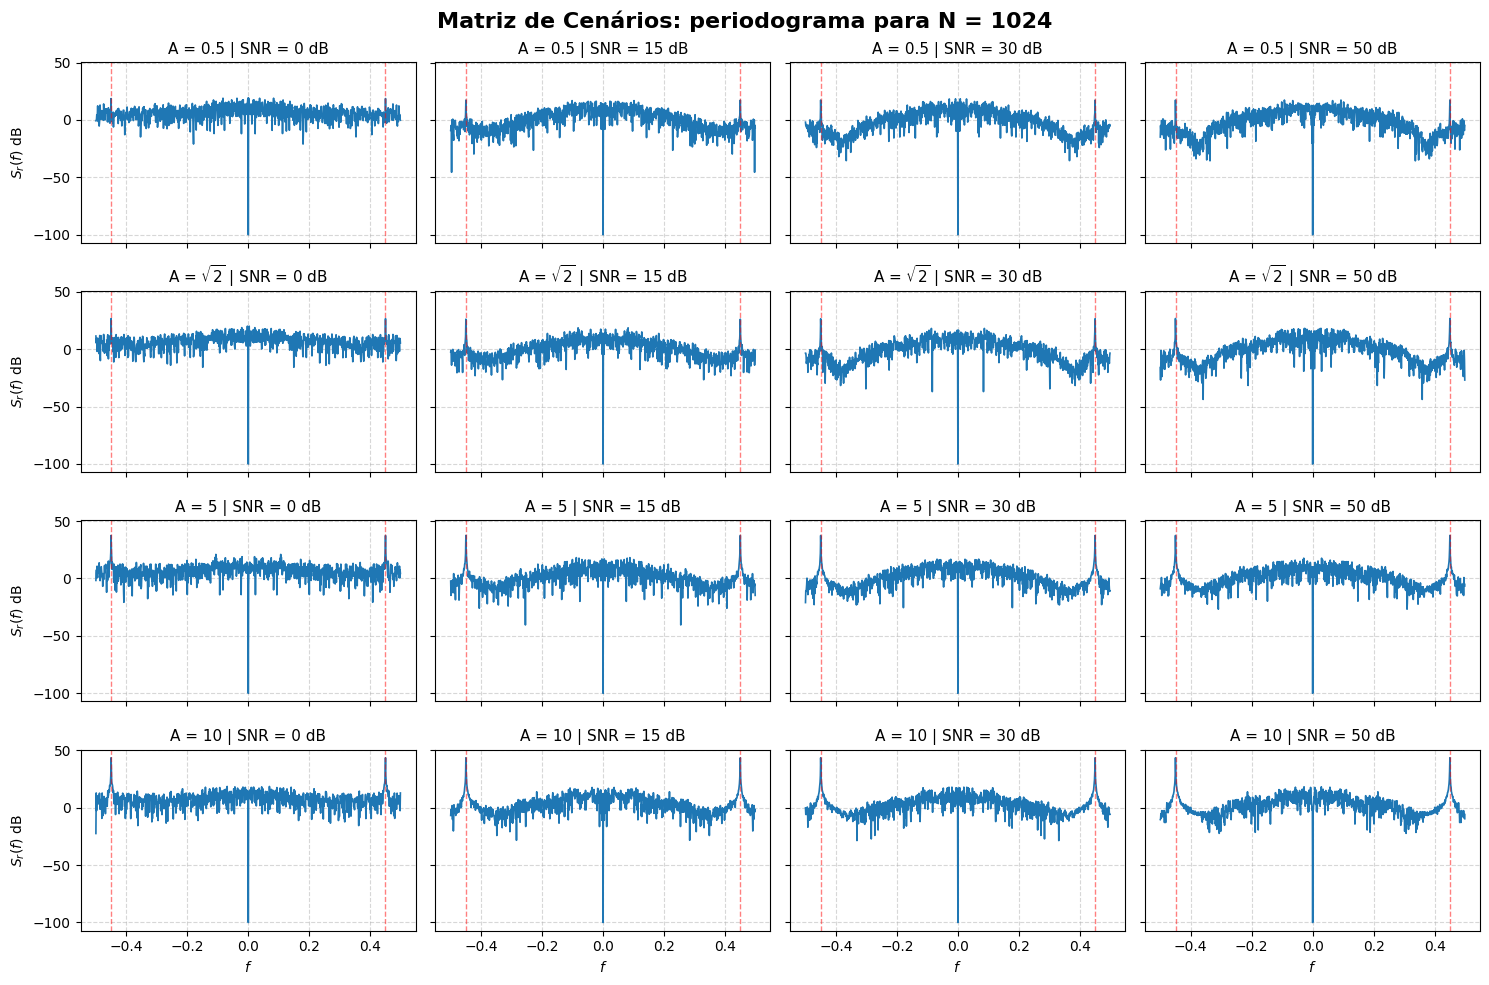

In [627]:
plot_scenario_matrix_freq(list = periodograms_1024, N = 1024, method = "periodograma", scale = "db")

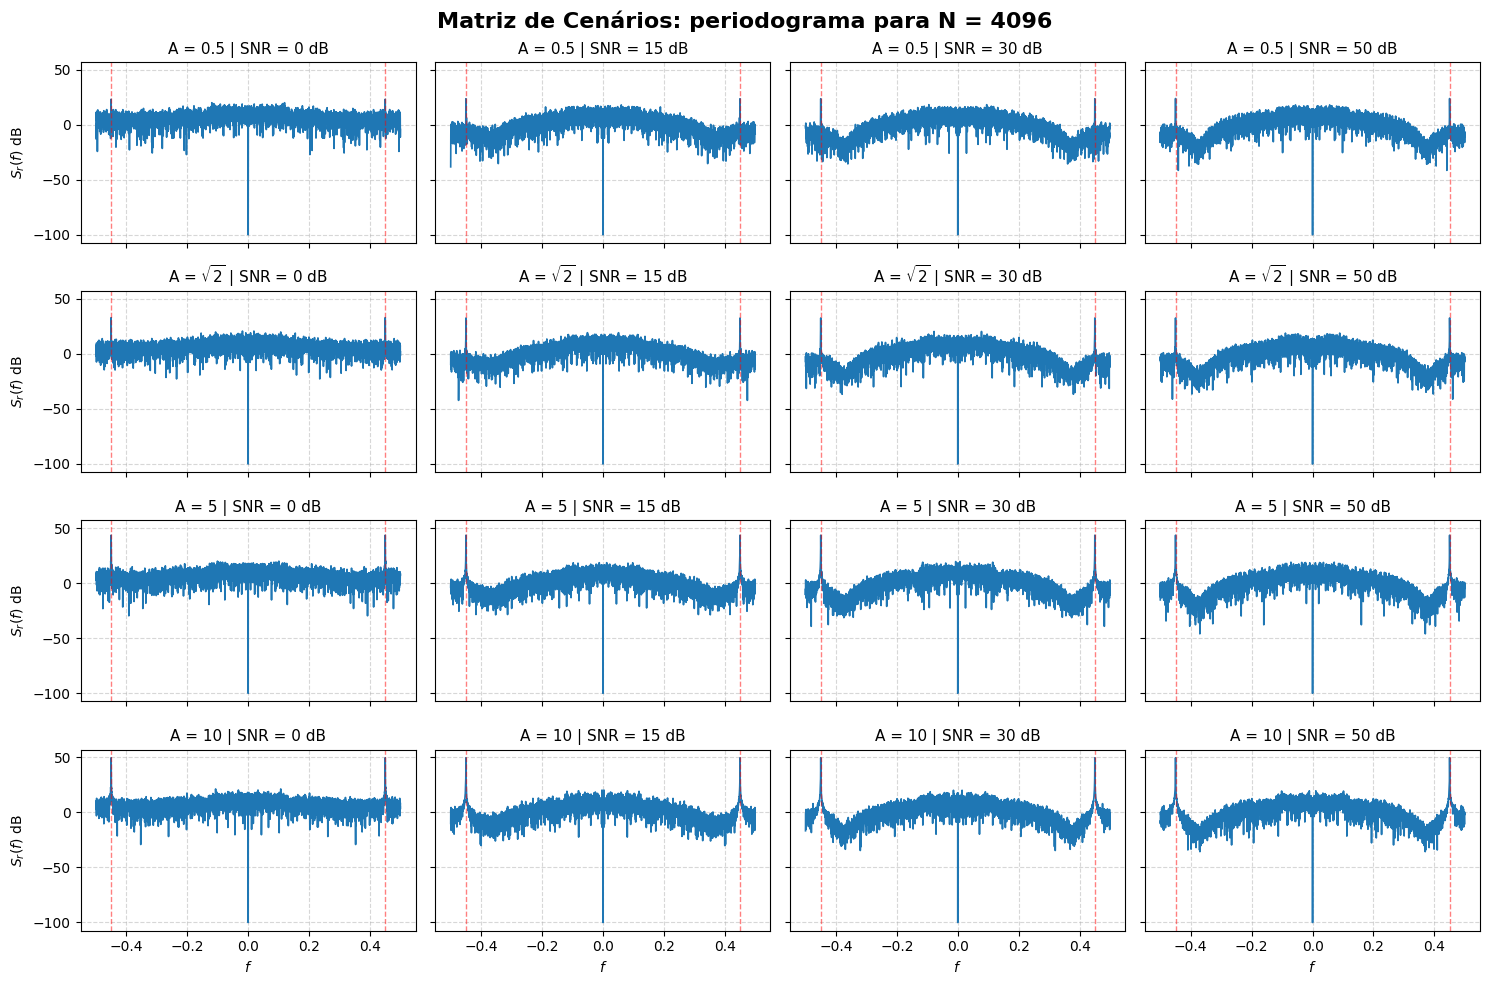

In [628]:

plot_scenario_matrix_freq(list = periodograms_4096, N = 4096, method = "periodograma", scale = "db")

#### Calculando e plotando o método de Welch

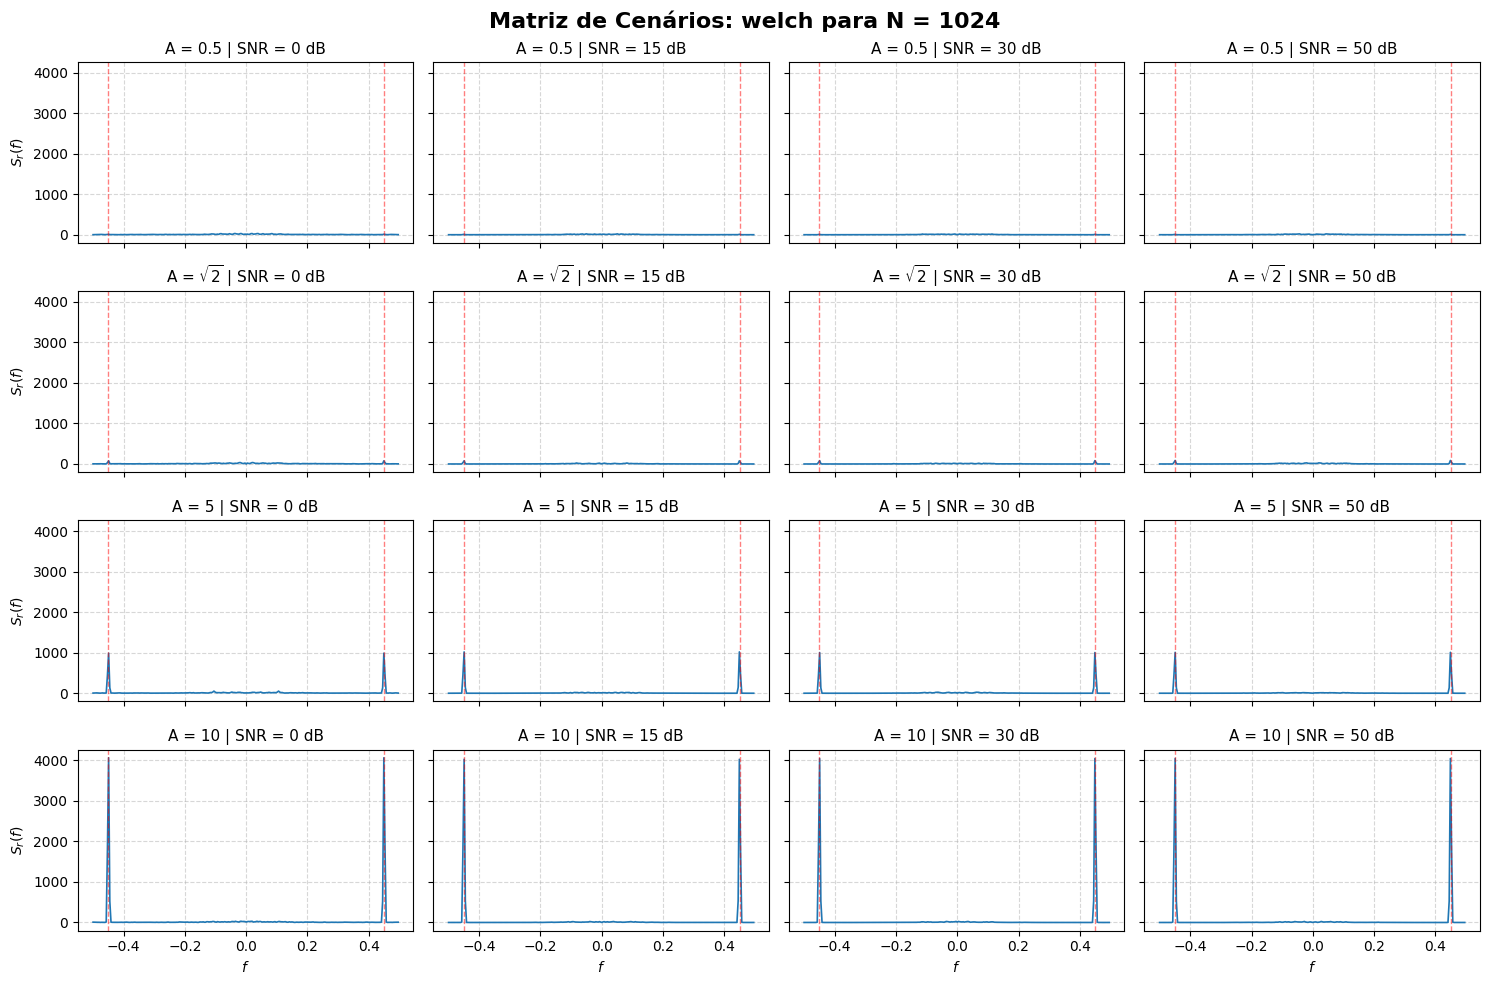

In [629]:
plot_scenario_matrix_freq(list = welch_1024, N = 1024, method = "welch")

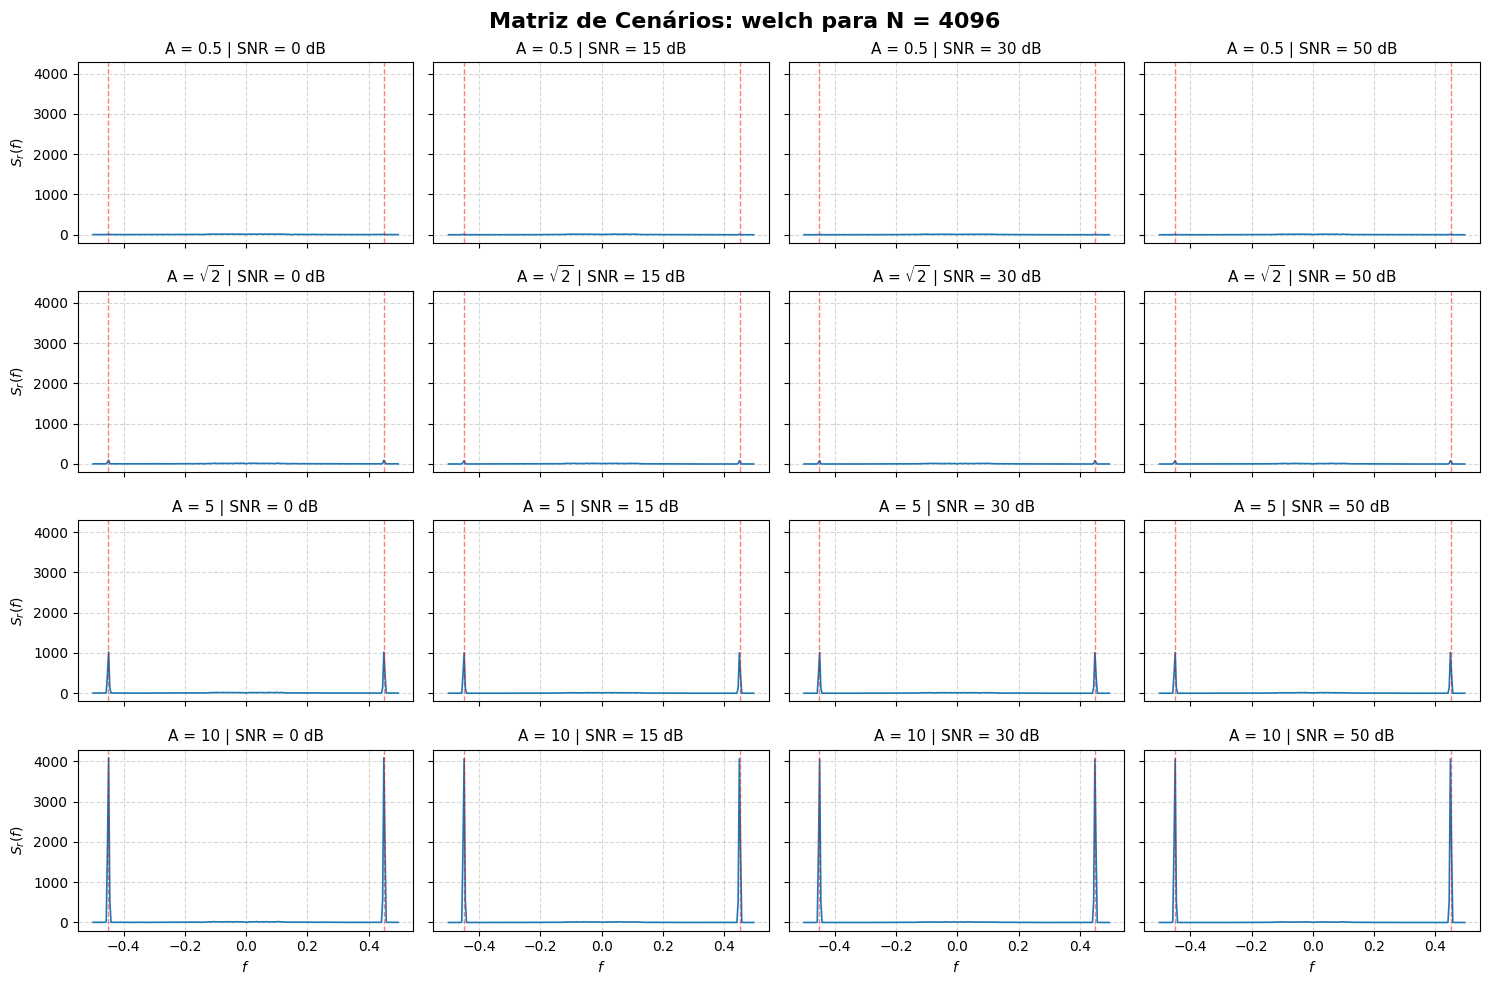

In [630]:
plot_scenario_matrix_freq(list = welch_4096, N = 4096, method = "welch")

#### Em escala logaritmica

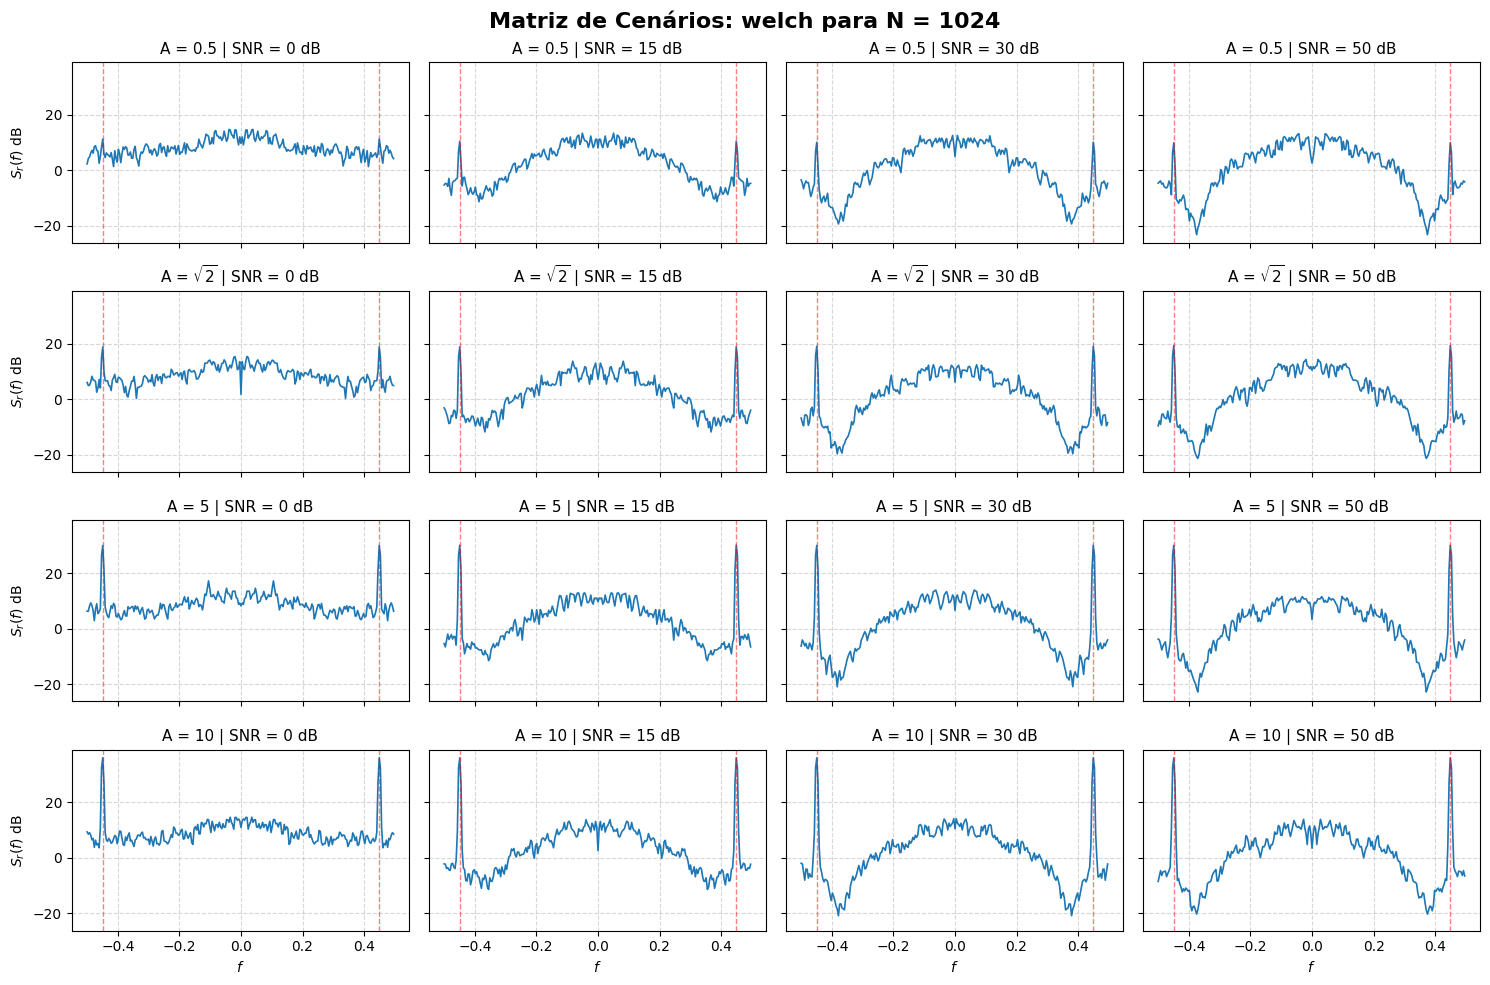

In [631]:
plot_scenario_matrix_freq(list = welch_1024, N = 1024, method = "welch", scale = 'db')

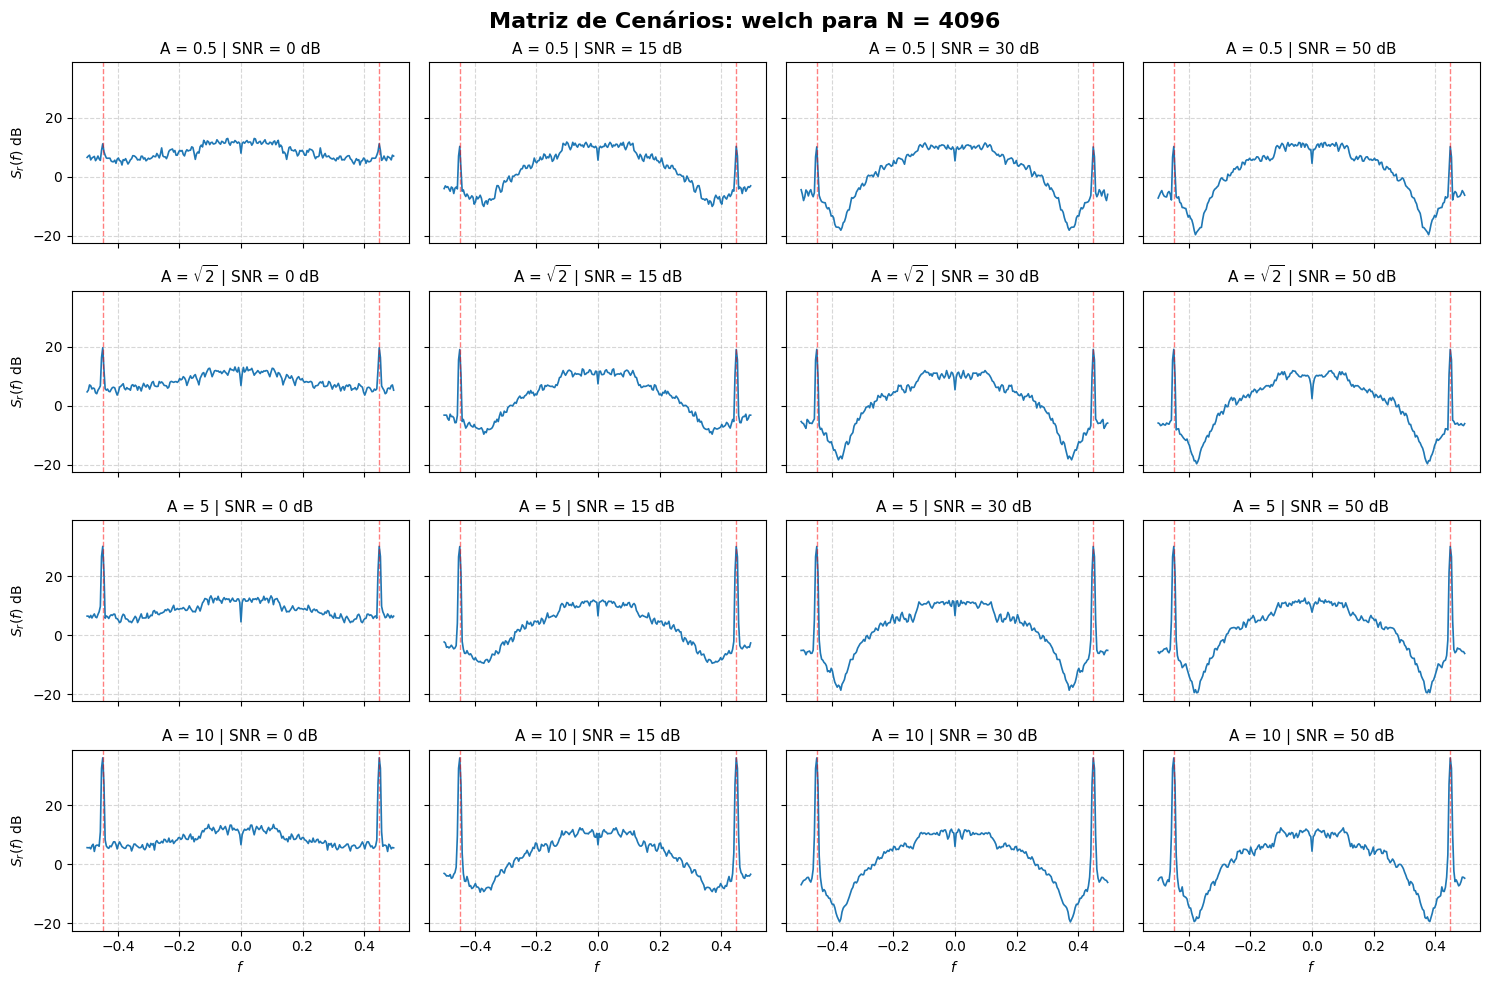

In [632]:
plot_scenario_matrix_freq(list = welch_4096, N = 4096, method = "welch", scale = 'db')

### OS COMENTARIOS ACERCA DOS PLOTS COMO UM TODO SE ECONTRAM NA TAREFA 6

## Tarefa 4

### Comparando as DEP adquiridas anteriormente com a teórica dada por:
$$S_r(f) = |H(f)|² S_{xx}(f) + \frac{A²}{4}[\delta(f-f_0) + \delta(f+f_0)] + \sigma_w^2$$

 Para comparar iremos utilizar o MSE $\frac{1}{N} \sum (y_i - \hat{y}_i) ^ 2$ em todas as 16 variantes geradas para os diferentes valores de $A$, $A_i \in \{0.5, \sqrt{2}, 5, 10\}$ e os direntes valores de variância ajustadas para os diferentes SNR obtidos pelos valores de $dB$, $dB_i \in \{0, 15, 30, 50\}$ tanto para a versão com 1024 quanto a com 4096 amostras

In [633]:
def mse(estimado, teorico):
    erro = np.mean((np.array(estimado) - np.array(teorico))**2)
    return erro

In [634]:
def H(f):
    return 1 + alpha * np.exp(-1j * 2 * np.pi * f * D)

def Sx(f):
    return 1 /(np.abs(1 - a1 * np.exp(-1j*2*np.pi*f) - a2 * np.exp(-1j*4*np.pi*f))) ** 2

In [635]:
def Sr(f, sig, A):
    Hf = H(f)
    Hf2 = np.abs(Hf)**2
    Sxf = Sx(f)
    var = var_given_db(sig, 15)
    impulso = np.zeros_like(f)
    idx_f0_pos = np.argmin(np.abs(f - f0))
    idx_f0_neg = np.argmin(np.abs(f - (-f0))) 
    impulso[idx_f0_neg] += (A**2) / 4
    impulso[idx_f0_pos] += (A**2) / 4

    return Hf2 * Sxf + impulso + var

In [636]:
Sr_1024_period = []
Sr_1024_welch = []
Sr_4096_period = []
Sr_4096_welch = []

MSE_Sr_period_1024 = []
MSE_Sr_period_4096 = []
MSE_Sr_welch_1024 = []
MSE_Sr_welch_4096 = []

### Calculando nos casos em N = 1024

In [637]:
for p_period, p_welch, sinal_original in zip(periodograms_1024, welch_1024, sinais_1024):
    
    A_val, snr_val, f_period, pxx_period = p_period
    _, _, f_welch, pxx_welch = p_welch
    
    vetor_temporal_y = sinal_original[2]
    
    sr_teo_period = Sr(f_period, vetor_temporal_y, A_val)
    sr_teo_welch = Sr(f_welch, vetor_temporal_y, A_val)
    
    Sr_1024_period.append((A_val, snr_val, f_period, sr_teo_period))
    Sr_1024_welch.append((A_val, snr_val, f_welch, sr_teo_welch))
    
    erro_period = mse(pxx_period, sr_teo_period)
    erro_welch = mse(pxx_welch, sr_teo_welch)
    
    MSE_Sr_period_1024.append((A_val, snr_val, erro_period))
    MSE_Sr_welch_1024.append((A_val, snr_val, erro_welch))

### Calculando nos cason em N = 4096

In [638]:
for p_period, p_welch, sinal_original in zip(periodograms_4096, welch_4096, sinais_4096):
    
    A_val, snr_val, f_period, pxx_period = p_period
    _, _, f_welch, pxx_welch = p_welch
    
    vetor_temporal_y = sinal_original[2]
    
    sr_teo_period = Sr(f_period, vetor_temporal_y, A_val)
    sr_teo_welch = Sr(f_welch, vetor_temporal_y, A_val)
    
    Sr_4096_period.append((A_val, snr_val, f_period, sr_teo_period))
    Sr_4096_welch.append((A_val, snr_val, f_welch, sr_teo_welch))
    
    erro_period = mse(pxx_period, sr_teo_period)
    erro_welch = mse(pxx_welch, sr_teo_welch)
    
    MSE_Sr_period_4096.append((A_val, snr_val, erro_period))
    MSE_Sr_welch_4096.append((A_val, snr_val, erro_welch))

#### Função para plot de comparação

In [639]:
def plot_comparacao_matriz_freq(lista_estimada, lista_teorica, N, method):
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 8), sharex=True, sharey=True)
    fig.suptitle(f'Validação Teórica vs Prática: {method} para N = {N}', fontsize=16, fontweight='bold', y=0.98)

    indice_sinal = 0

    for i, a in enumerate(As): 
        for j, db in enumerate(dbs):
            ax = axes[i, j]
            
            _, _, f_est, pxx_est = lista_estimada[indice_sinal]
            _, _, f_teo, pxx_teo = lista_teorica[indice_sinal]
            
            pxx_est_db = 10 * np.log10(np.maximum(pxx_est, 1e-10))
            pxx_teo_db = 10 * np.log10(np.maximum(pxx_teo, 1e-10))
            
            ax.plot(f_est, pxx_est_db, color='#1f77b4', linewidth=1.2, label='Estimado')
            
            ax.plot(f_teo, pxx_teo_db, color='red', alpha=1.0,linestyle='-', linewidth=0.5, label='Teórico')
            
            ax.axvline(x=0.45, color='green', linestyle=':', alpha=0.7, linewidth=1.2)
            ax.axvline(x=-0.45, color='green', linestyle=':', alpha=0.7, linewidth=1.2)
            
            if np.isclose(a, np.sqrt(2)):
                ax.set_title(f'A = $\sqrt{{2}}$ | SNR = {db} dB', fontsize=11)
            else:
                ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
           # ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
            
            if i == 3:
                ax.set_xlabel('$f$')
            if j == 0:
                ax.set_ylabel('$S_r(f)$ (dB/Hz)')
                
            if i == 0 and j == 0:
                ax.legend(loc='upper right', fontsize=8)
                
            indice_sinal += 1

    plt.tight_layout()
    plt.show()

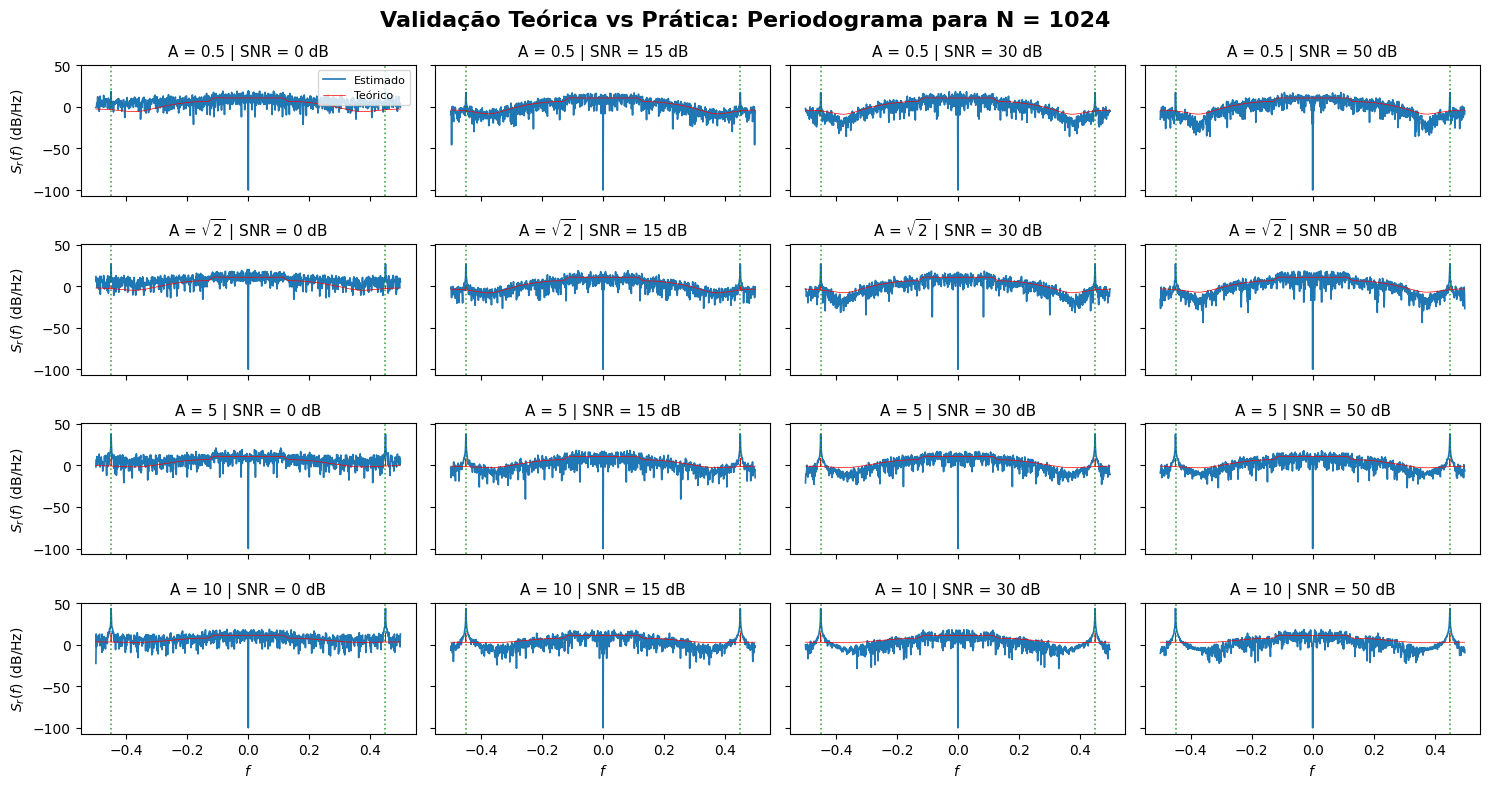

In [640]:
plot_comparacao_matriz_freq(periodograms_1024, Sr_1024_period, N = 1024, method='Periodograma')

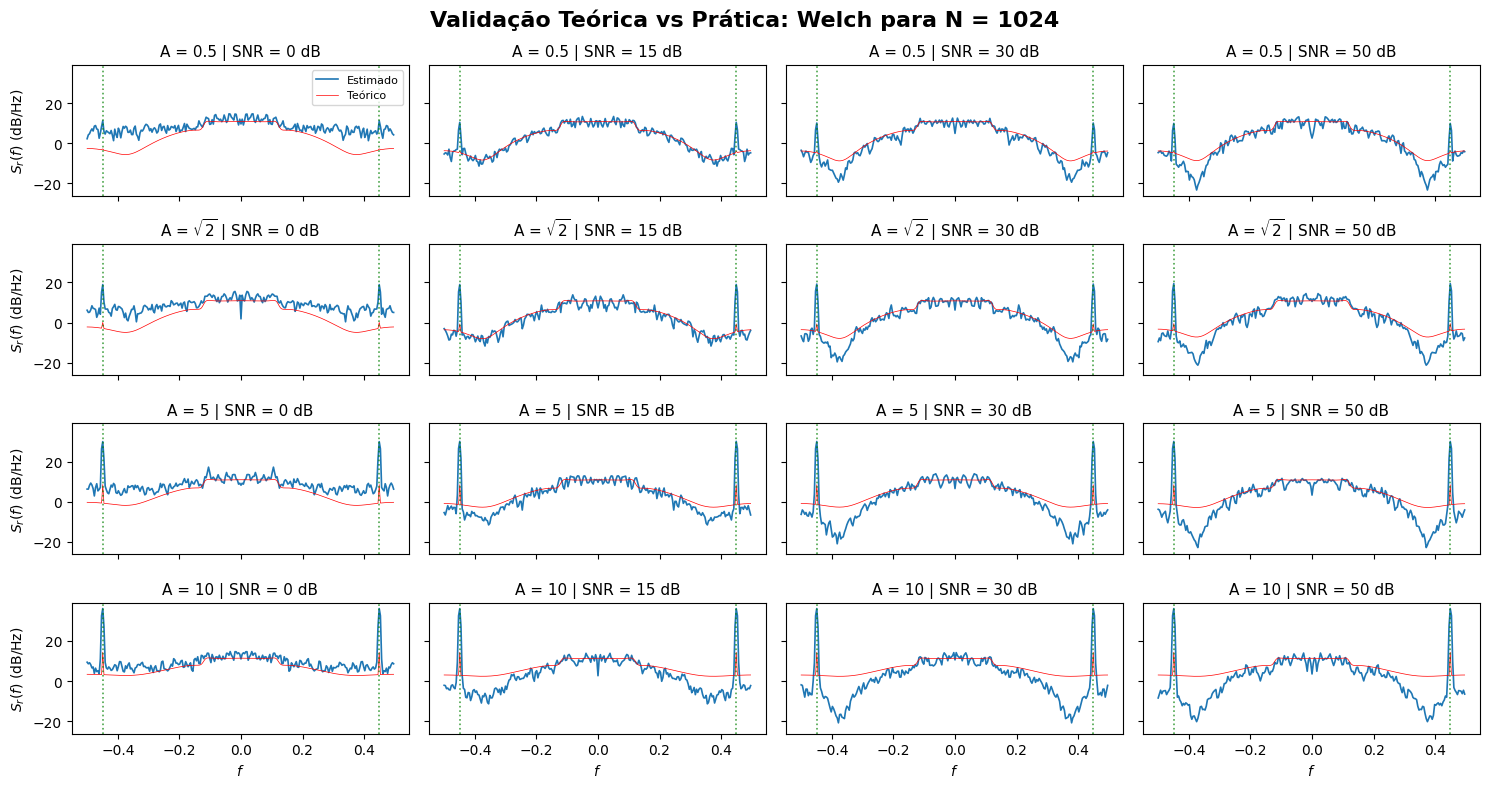

In [641]:
plot_comparacao_matriz_freq(welch_1024, Sr_1024_welch, N = 1024, method='Welch')

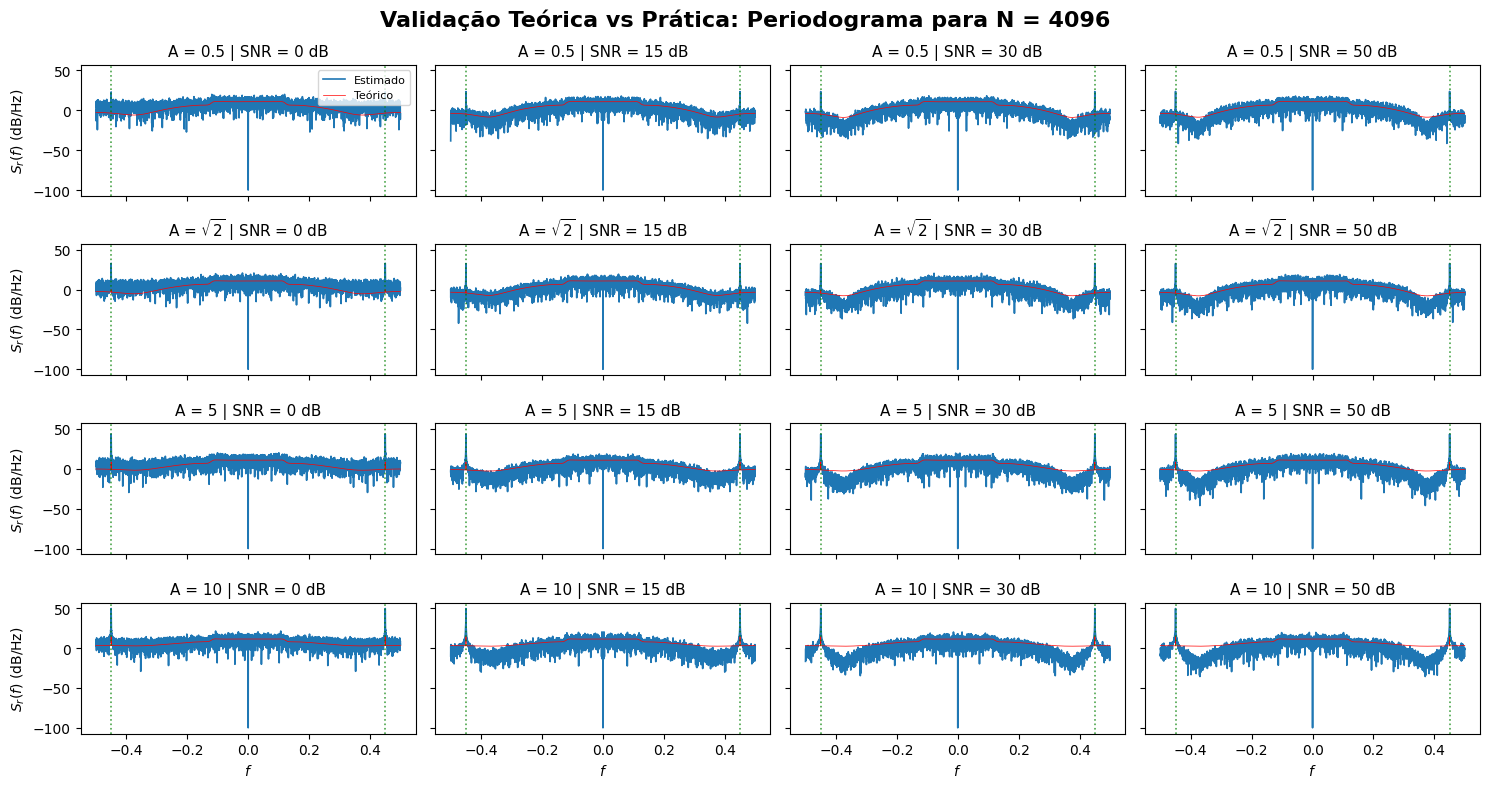

In [642]:
plot_comparacao_matriz_freq(periodograms_4096, Sr_4096_period, N = 4096, method='Periodograma')

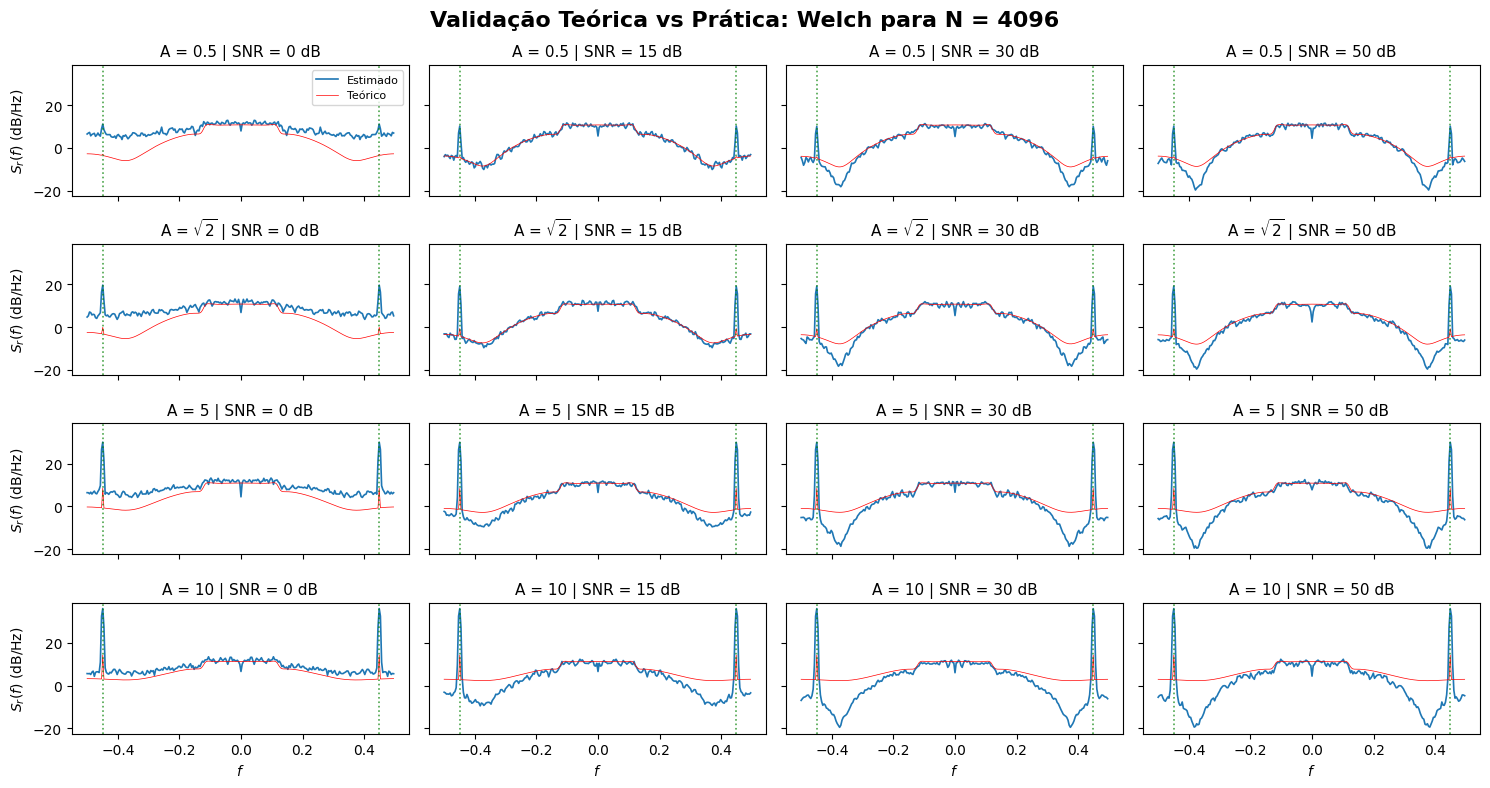

In [643]:
plot_comparacao_matriz_freq(welch_4096, Sr_4096_welch, N = 4096, method='Welch')

In [644]:
import pandas as pd
from IPython.display import display, HTML


def mse_to_table(mse_list, N, method):
    df = pd.DataFrame(mse_list, columns=["A", "SNR", "MSE"])
    df = (df.style.format("{:.2f}").hide(axis="index").set_caption(f"MSE comparando o teórico com o {method} para N={N}"))
    
    display(df)


In [645]:
mse_to_table(MSE_Sr_period_1024, 1024, 'periodograma')

A,SNR,MSE
0.50,0.00,123.73
0.50,15.00,37.64
0.50,30.00,46.87
0.50,50.00,32.81
1.41,0.00,541.95
1.41,15.00,377.40
1.41,30.00,429.69
1.41,50.00,504.65
5.00,0.00,59867.77
5.00,15.00,61478.54


In [646]:
mse_to_table(MSE_Sr_period_4096, 4096, 'periodograma')

A,SNR,MSE
0.50,0.00,106.98
0.50,15.00,56.47
0.50,30.00,52.51
0.50,50.00,58.41
1.41,0.00,1941.64
1.41,15.00,1611.61
1.41,30.00,1630.06
1.41,50.00,1655.26
5.00,0.00,248475.36
5.00,15.00,241567.18


In [647]:
mse_to_table(MSE_Sr_welch_1024, 1024, 'Welch')

A,SNR,MSE
0.50,0.00,29.23
0.50,15.00,4.82
0.50,30.00,3.53
0.50,50.00,6.35
1.41,0.00,90.76
1.41,15.00,62.47
1.41,30.00,66.35
1.41,50.00,77.65
5.00,0.00,9146.06
5.00,15.00,9744.73


In [648]:

mse_to_table(MSE_Sr_welch_4096, 4096, 'Welch')

A,SNR,MSE
0.50,0.00,15.84
0.50,15.00,2.14
0.50,30.00,2.26
0.50,50.00,2.30
1.41,0.00,98.75
1.41,15.00,63.86
1.41,30.00,64.17
1.41,50.00,65.14
5.00,0.00,9893.30
5.00,15.00,9466.15


Podemos ver que em todos os casos, os que apresentaram o menor MSE foi o cenário em que A = 0.5 e SNR = 30

## Tarefa 5

#### Variando o método de Welch com diferentes tamanho para as janelas, $L \in \{34, 128, 256, 512\}$ e analisando o impacto na variância da estimativa

Para não gerar 128 variações (para ambos os casos de N e os diferentes valores utilizados para A e o SNR), irei utilizar os seguintes cenários para tal tarefa:
- A = $10$ e SNR = 0
- A = $10$ e SNR = 15 
- A = $\sqrt{2}$ e SNR = 0
- A = $\sqrt{2}$ e SNR = 15

`Todos com N = 4096` 

In [649]:
# Funcao para se obter o caso desejado

def obter_sinal(sinais, A, snr):
    for s in sinais:
        if (np.isclose(s[0], A) and s[1] == snr):
            sig = s[2]
            return sig

# Funcao pra calcular o welch para cada tamanho L desejado
def aplicar_welch(sig, tamanhos=[34, 128, 256, 512]):
    ret = []
    for L in tamanhos:
        f, pxx = signal.welch(sig, nperseg=L, return_onesided=False)
        ret.append((np.fft.fftshift(f), np.fft.fftshift(pxx), L))
    return ret 

In [650]:
casos = [(10, 0),(10, 15),(np.sqrt(2), 0),(np.sqrt(2), 15)]

dados_processados = []

for x in casos:
    A_alvo = x[0]
    snr_alvo = x[1]
    sig = obter_sinal(sinais_4096, A_alvo, snr_alvo)
    casos = aplicar_welch(sig)
    dados_processados.append((A_alvo, snr_alvo, casos))

#### Plotando para os diferentes valores de L

In [651]:
def plotar_welch(casos, A, snr):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    if(np.isclose(A, np.sqrt(2))):
        plt.suptitle(f"Diferentes cenários para o Método de Welch com A = $\sqrt{{2}}$ e SNR = {snr}dB")
    else:
        plt.suptitle(f"Diferentes cenários para o Método de Welch com A = {A} e SNR = {snr}dB")
    
    for ax, (f, pxx, L) in zip(axs.flatten(), casos):
        ax.plot(f, 10 * np.log10(pxx))
        ax.axvline(x=0.45, color='red', linestyle=':', alpha=0.7, linewidth=1.2)
        ax.axvline(x=-0.45, color='red', linestyle=':', alpha=0.7, linewidth=1.2)
        ax.set_title(f'Metodo de welch com L = {L}')
        ax.grid(True)
    
    axs[0][0].set_ylabel("$S_r(f) dB$")
    axs[1][0].set_ylabel("$S_r(f) dB$")
    axs[1][0].set_xlabel("$f$")
    axs[1][1].set_xlabel("$f$")
    
    plt.tight_layout()
    plt.show()

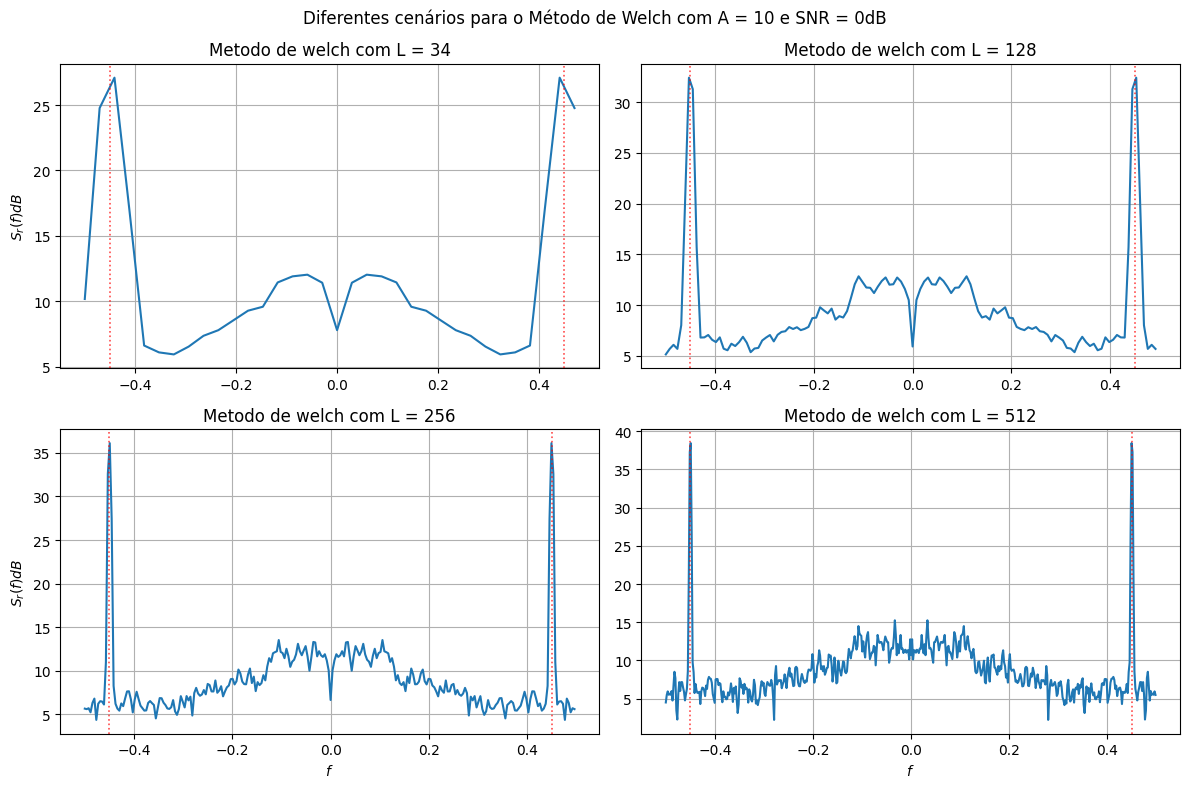

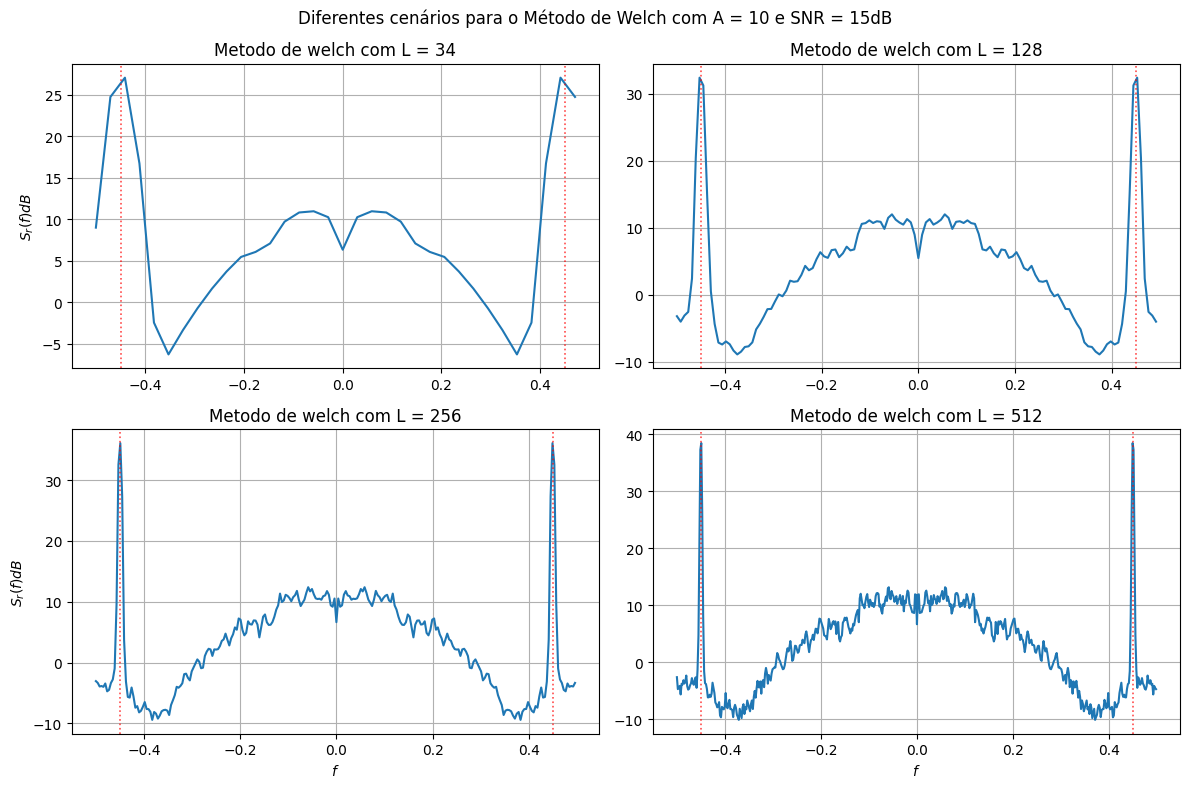

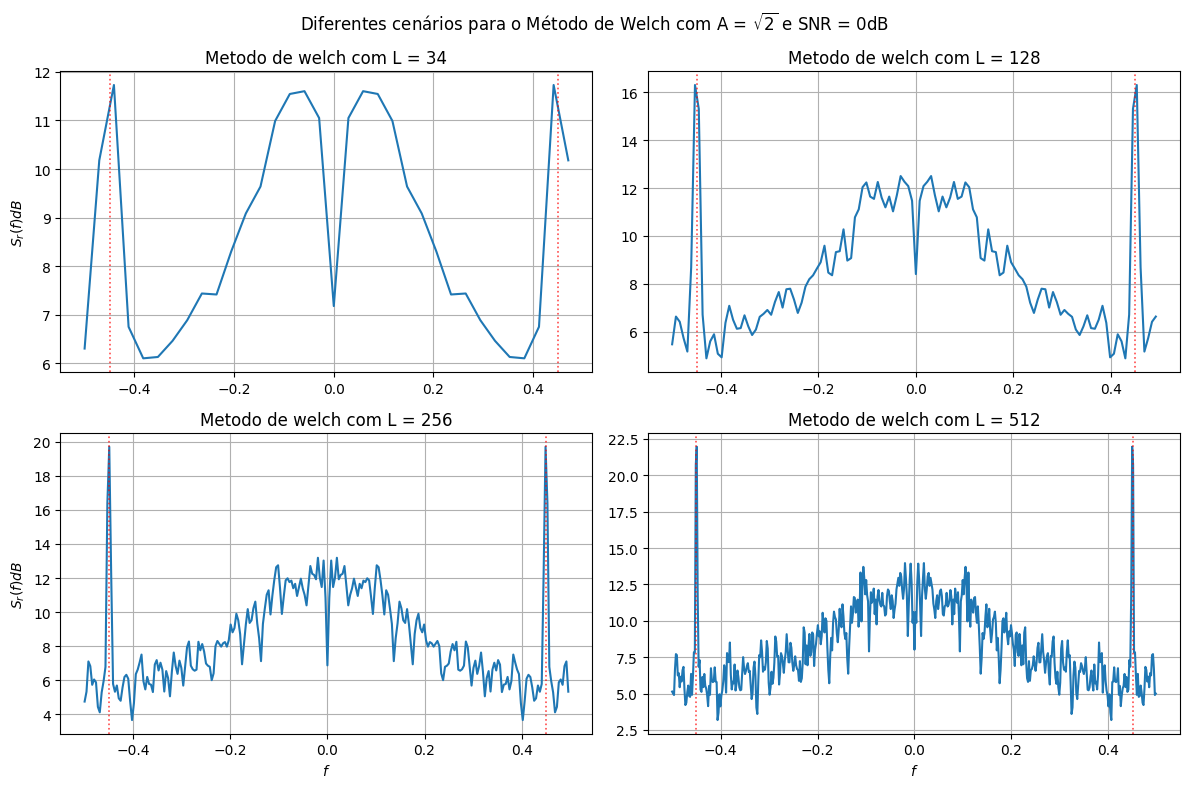

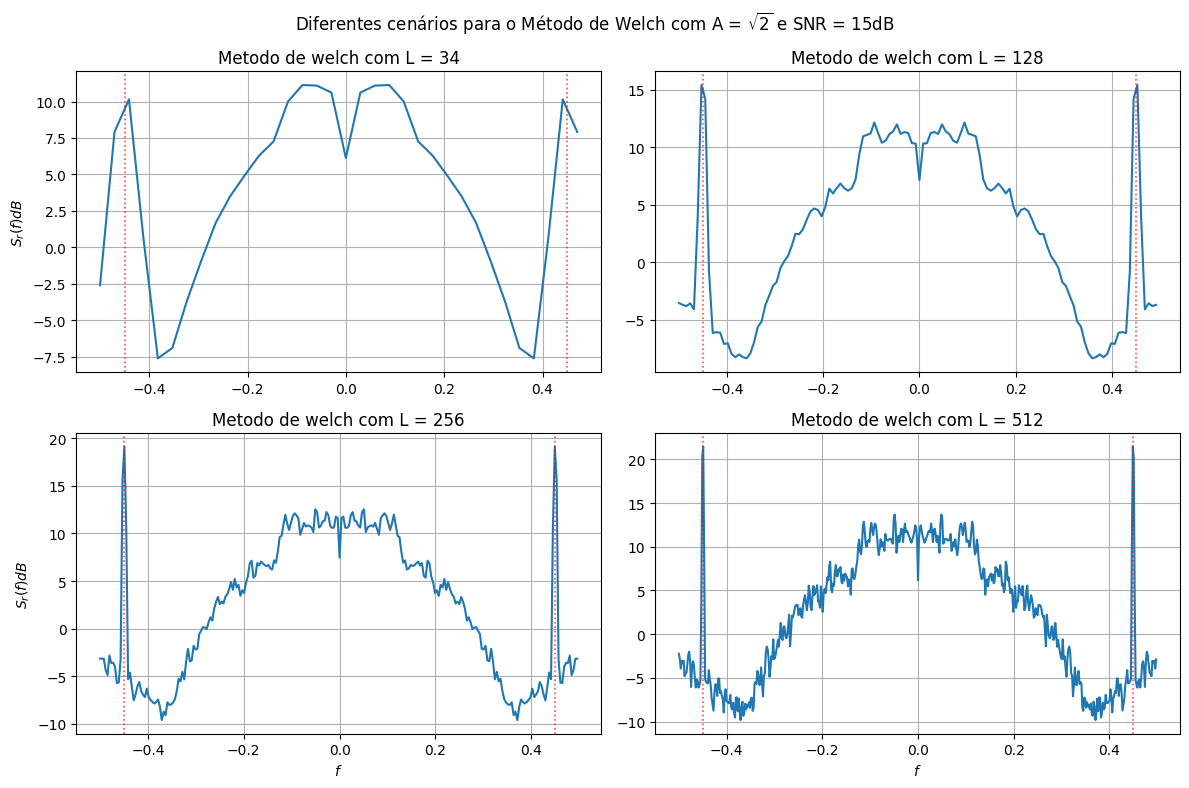

In [652]:
for A_alvo, snr_alvo, casos in dados_processados:
    plotar_welch(casos, A_alvo, snr_alvo)

In [653]:
def exibir_variancias(casos):
    vars_lista = [(L, np.var(pxx)) for f, pxx, L in casos]
    df = pd.DataFrame(vars_lista, columns=["L", "Var"])
    display(df.style.format("{:.2f}").hide(axis="index"))

In [654]:
for A, snr, casos in dados_processados:
    print(f"Variâncias para A = {A:.3f} | SNR = {snr} dB")
    exibir_variancias(casos)
    print("\n")

Variâncias para A = 10.000 | SNR = 0 dB


L,Var
34.00,17582.80
128.00,72713.44
256.00,155444.77
512.00,299243.44




Variâncias para A = 10.000 | SNR = 15 dB


L,Var
34.00,17447.87
128.00,72056.21
256.00,153629.19
512.00,296818.55




Variâncias para A = 1.414 | SNR = 0 dB


L,Var
34.00,15.62
128.00,47.95
256.00,88.12
512.00,158.00




Variâncias para A = 1.414 | SNR = 15 dB


L,Var
34.00,21.00
128.00,47.15
256.00,81.74
512.00,141.29


Podemos ver que à medida que o tamanho da janela aumenta, a variância da estimativa também aumenta. Isso ocorre devido ao tradeoff entre viés e variância, um comportamento natural quando trabalhamos com métodos de estimação espectral. Ou seja, à medida que a janela cresce, a resolução em frequência melhora e o viés diminui, fazendo com que a estimativa fique muito mais próxima do comportamento real do sinal original. No entanto, como o número total de amostras é fixo, usar janelas maiores significa fatiar o sinal em uma quantidade menor de blocos. Com menos segmentos disponíveis para o cálculo da média estatística, o algoritmo perde a sua força para suavizar o ruído de fundo, o que faz a curva estimada oscilar mais e eleva a variância do resultado final.

No método de Welch, o tamanho da janela ($L$) dita a quantidade de segmentos em que o sinal total será dividido. Se $L$ for grande, o sinal é dividido em poucos segmentos, com menos segmentos disponíveis para o cálculo da média, o cancelamento do ruído presente é ineficiente, resultando em uma curva com maiores oscilações (alta variância). Inversamente, se $L$ for pequeno, o sinal é dividido em mais blocos. A média calculada sobre uma grande quantidade de segmentos suaviza  as flutuações do ruído de fundo, produzindo uma estimativa visivelmente mais "estável" (baixa variância)

## Tarefa 6

Analisando os gráficos gerados anteriormente nesse notebook, conseguimos concluir que o método de Welch permite verificar visualmente com maior precisão $f_0$. Isso ocorre devido ao método do periodograma apresentar diversos "micropicos" que ocorrem com uma grande frequência podendo em alguns casos em que o valor de $A$ é relativamente pequeno se "misturar" com a frequência alvo nos picos que buscamos.

O método de welch apresentou melhor desempenho, principalmente no caso testado em que $A = 10$ e $SNR = 0dB$, ou seja, mesmo em um cenário onde a potência do ruído é exatamente igual à potência do sinal recebido, mascarando as frequências do sistema, o método demonstrou uma boa eficácia.

**Valores limites de $A$**

Para os valores testados, foi possível perceber que para valores abaixo de $\sqrt{2}$ (o qual configura amplitude unitária), os métodos apresentaram uma certa dificuldade em identificar $f_0$, em contrapartida, também se notou que a medida que $A$ aumenta, essa dificuldade diminui, tendo em vista que a potência é diratamente proporcional ao quadrado de A ($P$ $\alpha$ $A^2$) porém há um efeito adverso nas frequências vizinhas, a energia "transborda" um pouco para elas.


**Resolução Mínima**

Podemos ver que quando a resolução é baixa ($L = 34$), acaba agravando o que foi descrito anteriormente, ou seja, há um efeito de "vazamento" (Spectral Leakage) para as frequências vizinhas ao invés de a potência estar concentrada em $f_0$.

Além disso, foi possível aferir também que quando a resolução é muito grande ($L = 512$), a variância aumenta consideravelmente, podendo impactar negativamente em algumas análises dependendo do que se deseja averiguar.

Com isso, podemos dizer que a resolução recomendada seria algo entre 128 e 256


## Tarefa 7

Para calcular a SNR iremos utilizar a seguinte fórmula 
$${SNR}_{\text{est}} = 10 \log_{10} \left( \frac{P_{\text{sinal\_puro}}}{P_{\text{ruído\_total}}} \right)$$

A escolha dos intervalos para as sub-bandas do sinal util e do ruido se deu por
meio da análise visual nos gráficos gerados na tarefa 5, onde foi possível
visualizar que na maioria dos casos no intervalo $(-0.2, 0.2)$ encontrava-se a
parte principal da energia do nosso sinal. A partir de
$0.20$, essa curva cai e praticamente desaparece.Para medir o ruído,
definimos a faixa entre $0.25$ e $0.40$, criando uma "zona segura"
de medição a qual começa depois que o sinal principal já desceu e termina antes de
encostar no pico de $f_0$, que está cravado em $0.45$. Na teoria, essa
área deveria conter apenas o ruído do sistema.

In [655]:
def estimar_snr(f, pxx, L, snr_teorica):
    m_sinal = (np.abs(f) <= 0.20)
    m_ruido = (np.abs(f) >= 0.25) & (np.abs(f) <= 0.40)
    
    n0 = np.mean(pxx[m_ruido])
    p_ruido = n0 * 1.0 
    
    p_sinal_ruido = np.trapezoid(pxx[m_sinal], f[m_sinal])
    bw_sinal = f[m_sinal][-1] - f[m_sinal][0]
    p_sinal = p_sinal_ruido - (n0 * bw_sinal)
    
    snr_est = 10 * np.log10(np.maximum(p_sinal / p_ruido, 1e-10))
    
    print(f"L={L:3d} | SNR Teórica={snr_teorica:2d}dB | P_Ruído={p_ruido:.4f} | P_Sinal={p_sinal:.4f} | SNR_Est={snr_est:.2f}dB")

In [656]:
for A_alvo, snr_alvo, casos in dados_processados:
    print(f"ESTIMATIVAS PARA A = {A_alvo:.3f} | SNR = {snr_alvo} dB")
    resultados_snr = [estimar_snr(f, pxx, L, snr_alvo) for f, pxx, L in casos]
    print("-" * 60)

ESTIMATIVAS PARA A = 10.000 | SNR = 0 dB
L= 34 | SNR Teórica= 0dB | P_Ruído=4.5090 | P_Sinal=2.8574 | SNR_Est=-1.98dB
L=128 | SNR Teórica= 0dB | P_Ruído=4.5044 | P_Sinal=3.3194 | SNR_Est=-1.33dB
L=256 | SNR Teórica= 0dB | P_Ruído=4.5023 | P_Sinal=3.3133 | SNR_Est=-1.33dB
L=512 | SNR Teórica= 0dB | P_Ruído=4.3780 | P_Sinal=3.5145 | SNR_Est=-0.95dB
------------------------------------------------------------
ESTIMATIVAS PARA A = 10.000 | SNR = 15 dB
L= 34 | SNR Teórica=15dB | P_Ruído=0.7136 | P_Sinal=2.9028 | SNR_Est=6.09dB
L=128 | SNR Teórica=15dB | P_Ruído=0.6167 | P_Sinal=3.3234 | SNR_Est=7.32dB
L=256 | SNR Teórica=15dB | P_Ruído=0.6129 | P_Sinal=3.3579 | SNR_Est=7.39dB
L=512 | SNR Teórica=15dB | P_Ruído=0.6239 | P_Sinal=3.3992 | SNR_Est=7.36dB
------------------------------------------------------------
ESTIMATIVAS PARA A = 1.414 | SNR = 0 dB
L= 34 | SNR Teórica= 0dB | P_Ruído=4.6081 | P_Sinal=2.4847 | SNR_Est=-2.68dB
L=128 | SNR Teórica= 0dB | P_Ruído=4.7198 | P_Sinal=3.0317 | SNR_E

Os resultados encontrados demonstram que a eficácia da estimação de SNR depende do nível de ruído AWGN do sistema.

Em ambientes mais ruidosos onde o SNR fica 0 dB, o método apresentou maior
robustez. O ruído fica predominantemente na zona definida (0.25, 0.40),
permitindo que a função calcule uma SNR relativamente próxima da teórica, especialmente
em janelas de maior resolução como L = 256.

Por outro lado, o método revelou uma limitação em cenários 
com SNR maior (15 dB), ou seja, com menos ruído, onde a estimativa travou em um limite superior com valor $\in (7, 8)$ 
dB, tanto para interferências fortes (A = 10) quanto fracas (A = $\sqrt{2}$).
